<a href="https://colab.research.google.com/github/marcinwolter/MachineLearning-KISD-2026/blob/main/lecture4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

#  
# **<font color = "red">Introduction to machine learning</font>**
## Lecture 4

## **<font color = "green">Deep Neural Networks <br> a detailed tutorial</font>**

*25 March 2026*


---

*Marcin Wolter, IFJ PAN*

*e-mail: marcin.wolter@ifj.edu.pl*


---
</center>

#<font color='green'>**Program for today:**


* <font color='red'> Deep Neural Networks - a tutorial</font>
* <font color='red'> Convolutional Neural Networks - how to work with images?</font>
* <font color='red'> Data augmentation - how to increase artificially the number of training data events?</font>

<br>


**As always all slides are here:**

*https://github.com/marcinwolter/MachineLearning-KISD-2026*


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture5/Screenshot%20from%202022-03-20%2020-41-56.png' width=600px>





---

---





---



<center>

#<font color='green'> **NEURAL NETWORKS**

</center>



---



---



---

# <font color = green> **Deep Neural Networks**






#**Machine Learning and Deep Learning**

<span style="color:#000000"> __Traditional ML \(BDT\, NN etc\)__ </span>  <span style="color:#000000"> – the scientist finds good\, well discriminating variables </span>  <span style="color:#000000">\(~10\)\, called “features”\, and performs classification using them as inputs for the ML algorithm\.</span>

<span style="color:#000000"> __Deep Learning__ </span>  <span style="color:#000000"> – thousands or millions of input variables \(like pixels of a photo\)\, the features are </span>  <span style="color:#000000"> _automagically_ </span>  <span style="color:#000000"> extracted during training\.</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_643.png' width=650px>





* **Traditional Neural Networks** have one or two hidden layers\.

* <span style="color:#000000"> __Deep Neural Network:__ </span>  <span style="color:#000000"> a stack of sequentially trained </span>  <span style="color:#000000"> __auto encoders__ </span>  <span style="color:#000000">\, which recognize different features \(more complicated in each layer\) and automatically prepare a new representation of data\. This is how our brains are organized\.</span>







#<span style="color:#800000"><font color = green> __A tutorial – how to design and train a Keras DNN__ </span>

<span style="color:#000000">Task – build a simple network to recognize hand\-written digits:</span>

* <span style="color:#000000">60000 train samples</span>

* <span style="color:#000000">10000 test samples</span>



#**Keras & Tensorflow**

##**About Keras**

https://keras.io/

Keras is a deep learning API written in Python, running on top of the machine learning platform **TensorFlow**. It was developed with a focus on enabling fast experimentation. Being able to go from idea to result as fast as possible is key to doing good research.

Keras is:

* **Simple** -- but not simplistic. Keras reduces developer cognitive load to free you to focus on the parts of the problem that really matter.
* **Flexible** -- Keras adopts the principle of progressive disclosure of complexity: simple workflows should be quick and easy, while arbitrarily advanced workflows should be possible via a clear path that builds upon what you've already learned.
* **Powerful** -- Keras provides industry-strength performance and scalability: it is used by organizations and companies including NASA, YouTube, or Waymo.

---

##**Keras & TensorFlow 2**

https://www.tensorflow.org/

TensorFlow 2 is an end-to-end, open-source machine learning platform. You can think of it as an infrastructure layer for differentiable programming. It combines four key abilities:

* Efficiently executing low-level tensor operations on CPU, GPU, or TPU.
* Computing the gradient of arbitrary differentiable expressions.
* Scaling computation to many devices, such as clusters of hundreds of GPUs.
* Exporting programs ("graphs") to external runtimes such as servers, browsers, mobile and embedded devices.

Keras is the high-level API of TensorFlow 2: an approachable, highly-productive interface for solving machine learning problems, with a focus on modern deep learning. It provides essential abstractions and building blocks for developing and shipping machine learning solutions with high iteration velocity.

Keras empowers engineers and researchers to take full advantage of the scalability and cross-platform capabilities of TensorFlow 2: you can run Keras on TPU or on large clusters of GPUs, and you can export your Keras models to run in the browser or on a mobile device.




##**Training data** 28 x 28 pixels:

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_647.png' width=450px>

---






<span style="color:#000000">The first step is to define the functions and classes we intend to use in this tutorial\. We will use the </span>  <span style="color:#000000">[NumPy library](https://www.numpy.org/)</span>  <span style="color:#000000"> to load our dataset and we will use two classes from the </span>  <span style="color:#000000">[Keras library](https://keras.io/)</span>  <span style="color:#000000"> to define our model\.</span>

<span style="color:#000000">The imports required are listed below\.</span>


In [1]:
'''Trains a simple deep NN on the MNIST dataset.

Gets to 98.40% test accuracy after 20 epochs
(there is *a lot* of margin for parameter tuning).
2 seconds per epoch on a K520 GPU.
'''

from __future__ import print_function

import matplotlib.pyplot as plt
import numpy as np

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop, Adam

Define some parameters:

In [2]:
batch_size = 128  # size of the training batch
num_classes = 10  # number of classes. There are 10 different digits
epochs = 20       # number of training epochs


<span style="color:#000000">We can now load our dataset</span>

<span style="color:#000000"> __MNIST database of handwritten digits__ </span>

<span style="color:#000000">Dataset of 60\,000 28x28 grayscale images of the 10 digits\, along with a test set of 10\,000 images\.</span>

<span style="color:#000000"> __Usage:__ </span>

<span style="color:#000000">from keras\.datasets import mnist</span>

*\(x\_train\, y\_train\)\, \(x\_test\,y\_test\) = mnist\.load\_data\(\)*

<span style="color:#000000">    </span>  <span style="color:#000000"> __Returns__ </span>  <span style="color:#000000">:</span>

<span style="color:#000000">        </span>  <span style="color:#000000">2 tuples:</span>

<span style="color:#000000">            </span>  <span style="color:#000000">**x\_train\, x\_test:** uint8 array of grayscale image data with shape \(num\_samples\, 28\, 28\)\.</span>

<span style="color:#000000">            </span>  <span style="color:#000000">**y\_train\, y\_test:** uint8 array of digit labels \(integers in range 0\-9\) with shape \(num\_samples\,\)\.</span>

In [3]:
# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


We make now a numpy array of shape (60 000, 784) out of a python tuple

In [4]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

Convert to float32

In [5]:
# convert to float32

x_train = x_train.astype( 'float32' )
x_test = x_test.astype( 'float32' )

The value of each pixel is now between 0 and 255, we normalize it to the range (0,1)

In [6]:
#normalize to one

x_train /= 255
x_test /= 255


<span style="color:#800000"> **Prepare data: </span>  <span style="color:#800000"> convert to categorical**

<span style="color:#000000">We want to use NN with 10 outputs \(each corresponding to one digit\) to get a probability for each digit\. So we convert the y\_train from a single number to vector:</span>

7 → \(0\,  0\, 0\, 0\, 0\, 0\, 0\,  1\, 0\, 0\)</span>

0 → \(1\,  0\, 0\, 0\, 0\, 0\, 0\, 0\, 0\, 0\)</span>

9 → \(0\,  0\, 0\, 0\, 0\, 0\, 0\,  0\, 0\, 1\)</span>



In [7]:
# print info about a shape of arrays
print(x_train.shape, 'train samples')
print(x_test.shape, 'test samples')
print(y_train.shape, 'train samples')
print(y_test.shape, 'test samples')

# convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test =  tf.keras.utils.to_categorical(y_test, num_classes)


# print info about a shape of arrays
print(x_train.shape, 'train samples after conversion')
print(x_test.shape, 'test samples  after conversion')
print(y_train.shape, 'train samples after conversion')
print(y_test.shape, 'test samples  after conversion')

(60000, 784) train samples
(10000, 784) test samples
(60000,) train samples
(10000,) test samples
(60000, 784) train samples after conversion
(10000, 784) test samples  after conversion
(60000, 10) train samples after conversion
(10000, 10) test samples  after conversion



<span style="color:#800000"> __Define Keras Model__ </span>

<span style="color:#000000">Models in Keras are defined as a sequence of layers\.</span>

<span style="color:#000000">We create a Sequential model and add layers one at a time until we are happy with our network architecture\.</span>

<span style="color:#000000">The first thing to get right is to ensure the input layer has the right number of input features\. This can be specified when creating the first layer with 512 nodes and with the input\_dim argument and setting it to 784 for the 784 input variables\.</span>

<code>
<span style="color:#000000">model = Sequential()</span>

<span style="color:#000000">model\.add\(Dense\(</span>  <span style="color:#09885A">512</span>  <span style="color:#000000">\, activation=</span>  <span style="color:#A31515">'relu'</span>  <span style="color:#000000">\, input\_shape=\(</span>  <span style="color:#09885A">784</span>  <span style="color:#000000">\,\)\)\)</span>
</code>

<span style="color:#000000">The activation function is relu </span>
<span style="color:#000000">\(Rectified Linear\):</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_648.png' width=450px>

---


<span style="color:#000000"> __Adding next layers\. How do we know the number of layers and their types?__ </span>

<span style="color:#000000">This is a very hard question\. There are heuristics that we can use and often the best network structure is found through a process of trial and error experimentation\. Generally\, you need a network large enough to capture the structure of the problem\.</span>

<span style="color:#000000">In this example\, we will use a fully\-connected network structure with three hidden layers\.</span>

<span style="color:#000000">Fully connected layers are defined using the Dense class\. We can specify the number of neurons or nodes in the layer as the first argument\, and specify the activation function using the activation argument\.</span>

<span style="color:#000000">We will use the rectified linear unit activation function referred to as ReLU on the first three layers:</span>

<code>
model = Sequential()<br>
model.add(Dense(512, activation='relu', input_shape=(784,)))<br>
model.add(Dense(512, activation='relu'))<br>
model.add(Dense(512, activation='relu'))<br>
</code>


Adding output layer with num\_classes=10 nodes and softmax  activation function\. We use a softmax on the output layer to ensure our network outputs are between 0 and 1 and easy to map to either probabilities of all classes or snap to a hard classification of a class with maximum probability.



<span style="color:#800000"> __Softmax activation function__ </span>

Softmax function\, a wonderful activation function that turns numbers aka logits into probabilities that sum to one\. Softmax function outputs a vector that represents the probability distributions of a list of potential outcomes\. It’s also a core element used in deep learning classification tasks\.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_649.png' width=450px>
<br>


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_650.png' width=450px>

## **Dropout**

Between the layers we add a Dropout layer to avoid overtraining.

Dropout consists in randomly setting a fraction rate of input units to 0 at each update during training time\, which helps prevent overfitting\.



---


### “I went to my bank. The tellers kept changing and I asked one of them why. He said he didn’t know but they got moved around a lot. I figured it must be because it would require cooperation between employees to successfully defraud the bank. This made me realize that randomly removing a different subset of neurons on each example would prevent conspiracies and thus reduce overfitting.” — Geoffrey Hinton

<img src="https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2025/refs/heads/main/images/Zrzut%20ekranu%202025-03-25%20112940.png" width=450px>
<img src="https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2025/refs/heads/main/images/Zrzut%20ekranu%202025-03-25%20113154.png" width=450px>

*Original article:
[http://www\.jmlr\.org/papers/volume15/srivastava14a/srivastava14a\.pdf](http://www.jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)*




<mark> **Exercise:** try different Dropout values or skip dropout at all. </mark>

<mark>Try different activation functions and different number of nodes in the hidden layers.
</mark>

At the end we call:

<code>
<span style="color:#000000">model.summary()</span>  <span style="color:#000000"> </span>
</code>

  <span style="color:#000000"> print the network structure</span>


In [8]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,114 (1.28 MB)

 Trainable params: 335,114 (1.28 MB)

 Non-trainable params: 0 (0.00 B)


<span style="color:#800000"> __Train the network__ </span>





In [11]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(),  # we could also use RMSprop()
              metrics=['accuracy'])


When compiling\, we must specify some additional properties required when training the network\. Training a network means finding the best set of weights to map inputs to outputs in our dataset\.

* We must specify the loss function to use to evaluate a set of weights\, the optimizer is used to search through different weights for the network and any optional metrics we would like to collect and report during training\.

* This loss is for a categorical classification problems and is defined in Keras as “ _categorical\_crossentropy_ “\. You can learn more about choosing loss functions based on your problem here:

> [https://machinelearningmastery\.com/how\-to\-choose\-loss\-functions\-when\-training\-deep\-learning\-neural\-networks/](https://machinelearningmastery.com/how-to-choose-loss-functions-when-training-deep-learning-neural-networks/)

We will define the optimizer as the efficient stochastic gradient descent algorithm “ _RMSprop_ “\. We could also use “adam”\, which is a popular version of gradient descent because it automatically tunes itself and gives good results in a wide range of problems\.


#**A hint!!!**

Try using GPU - it makes DNN much faster!

In [12]:

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9026 - loss: 0.3187 - val_accuracy: 0.9641 - val_loss: 0.1199
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9603 - loss: 0.1324 - val_accuracy: 0.9706 - val_loss: 0.0953
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9694 - loss: 0.0982 - val_accuracy: 0.9726 - val_loss: 0.0905
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9750 - loss: 0.0793 - val_accuracy: 0.9786 - val_loss: 0.0682
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9789 - loss: 0.0678 - val_accuracy: 0.9769 - val_loss: 0.0782
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9806 - loss: 0.0619 - val_accuracy: 0.9802 - val_loss: 0.0635
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9833 - loss: 0.0522 - val_accuracy: 0.9821 - val_loss: 0.0604
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9846 - loss: 0.0486 - val_accuracy: 0



We can train or fit our model on our loaded data by calling the fit\(\) function on the model\.
Training occurs over epochs and each epoch is split into batches\.

* **Epoch:** One pass through all of the rows in the training dataset\.

* **Batch:**  One or more samples considered by the model within an epoch before weights are updated\.

One epoch is comprised of one or more batches\, based on the chosen batch size\.
For our digit recognition\, we will run for a small number of epochs \(20\) and use a  batch size of 128\.

These configurations can be chosen experimentally by trial and error\. We want to train the model enough so that it learns a good \(or good enough\) mapping of rows of input data to the output classification\. The model will always have some error\, but the amount of error will level out after some point for a given model configuration\. This is called model convergence\.

---

<span style="color:#800000"> __Evaluate Keras Model__ </span>

We have trained our neural network on the entire dataset and we can evaluate the performance of the network on another “test” dataset\.

You can evaluate your model on a dataset using the evaluate\(\) function\.

This will generate a prediction for each input and output pair and collect scores\, including the average loss and any metrics you have configured\, such as accuracy\.

The evaluate\(\) function will return a list with two values\. The first will be the loss of the model on the dataset and the second will be the accuracy of the model on the dataset\.



In [13]:
score = model.evaluate(x_test, y_test, verbose=1)
print('Test accuracy:', score[1])



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9823 - loss: 0.0756
Test accuracy: 0.9822999835014343


#**Score:**

We got over 98.1% - 98.6% of good answers! Let's compare it with our previous MNIST classifiers:
* PCA + Naive Bayes - 94.8%
* Shallow neural network 97.7%





#<span style="color:#800000"> __Program with more features__ </span>


* <span style="color:#000000">Visualization of results</span>

* <span style="color:#000000">Plotting the Neural Network structure</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/MachineLearning2020_651.png' width=450px>


In [14]:
'''Trains a simple deep NN on the MNIST dataset.

Gets to 98.40% test accuracy after 20 epochs
(there is *a lot* of margin for parameter tuning).
2 seconds per epoch on a K520 GPU.
'''

from __future__ import print_function

import matplotlib.pyplot as plt
import numpy as np

import keras
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop, Adam

from keras.utils import plot_model
from IPython.display import Image

batch_size = 128
num_classes = 10
epochs = 20

# the data, split between train and test sets
(x_train, y_train0), (x_test, y_test0) = mnist.load_data()

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train0, num_classes)
y_test = tf.keras.utils.to_categorical(y_test0, num_classes)



60000 train samples
10000 test samples


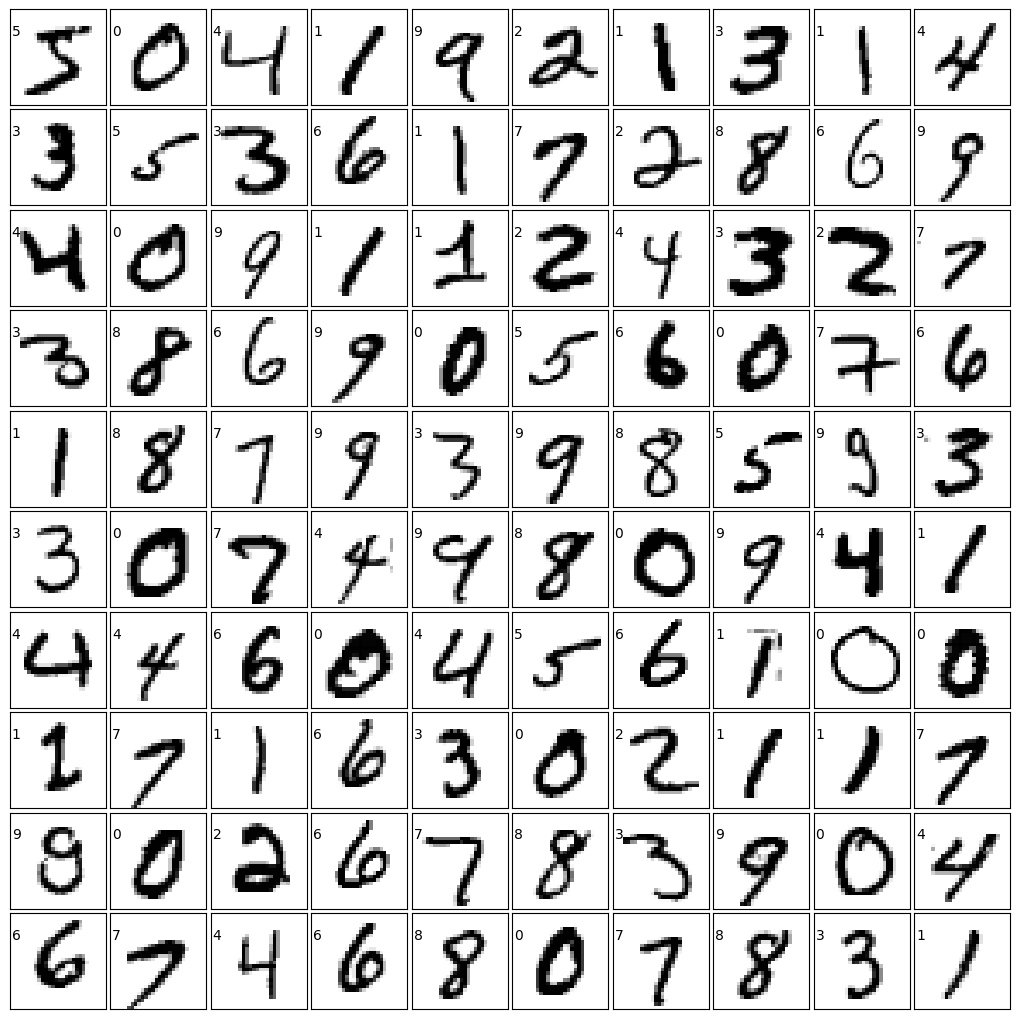

In [15]:
#visualize the digits

fig = plt.figure(figsize=(10, 10))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(100):
    ax = fig.add_subplot(10, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(x_train[i].reshape(28,28), cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 7, str(y_train0[i]))

In [16]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,114 (1.28 MB)

 Trainable params: 335,114 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

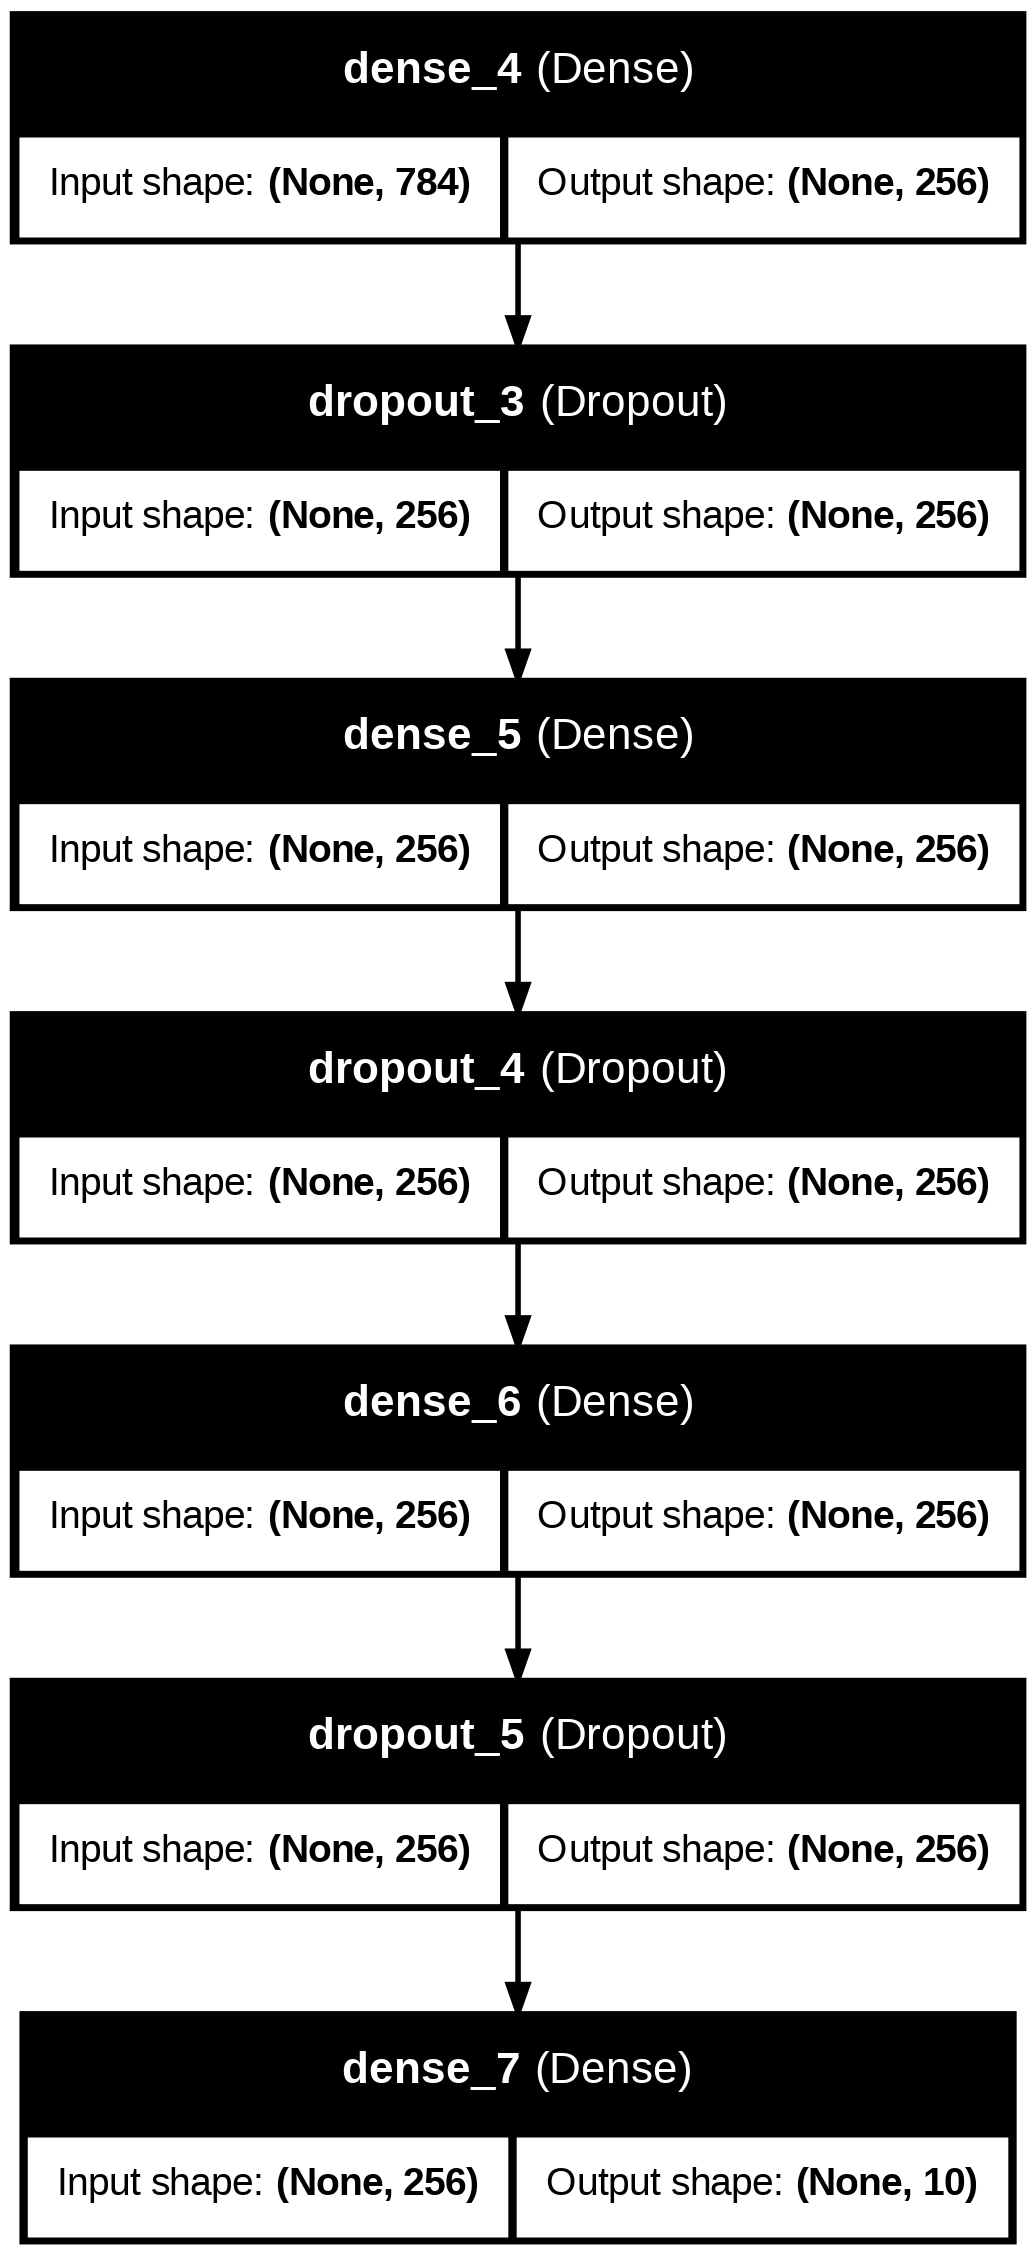

In [17]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
Image('model_plot.png')

In [18]:
model.compile(loss='categorical_crossentropy',
              optimizer="adam",
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9010 - loss: 0.3251 - val_accuracy: 0.9582 - val_loss: 0.1318
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9600 - loss: 0.1310 - val_accuracy: 0.9730 - val_loss: 0.0827
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9698 - loss: 0.0986 - val_accuracy: 0.9756 - val_loss: 0.0788
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9754 - loss: 0.0804 - val_accuracy: 0.9770 - val_loss: 0.0728
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9780 - loss: 0.0687 - val_accuracy: 0.9793 - val_loss: 0.0623
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9817 - loss: 0.0581 - val_accuracy: 0.9804 - val_loss: 0.0674
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9847 - loss: 0.0487 - val_accuracy: 0.9759 - val_loss: 0.0803
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9845 - loss: 0.0485 - val_accuracy: 0

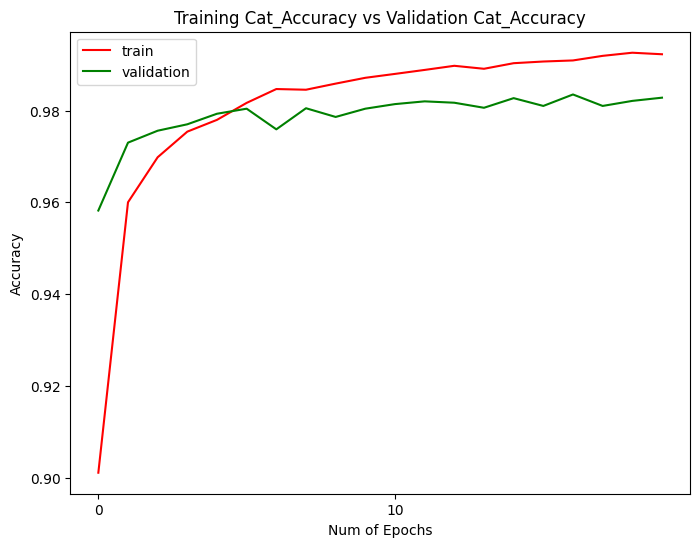

In [19]:
# Plots for training and testing process: loss and accuracy

n_epochs = len(history.history['loss'])

plt.figure(0, figsize=(8, 6))
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'g')
plt.xticks(np.arange(0, n_epochs, 10.0))

plt.xlabel("Num of Epochs")
plt.ylabel("Accuracy")
plt.title("Training Cat_Accuracy vs Validation Cat_Accuracy")
plt.legend(['train','validation'])



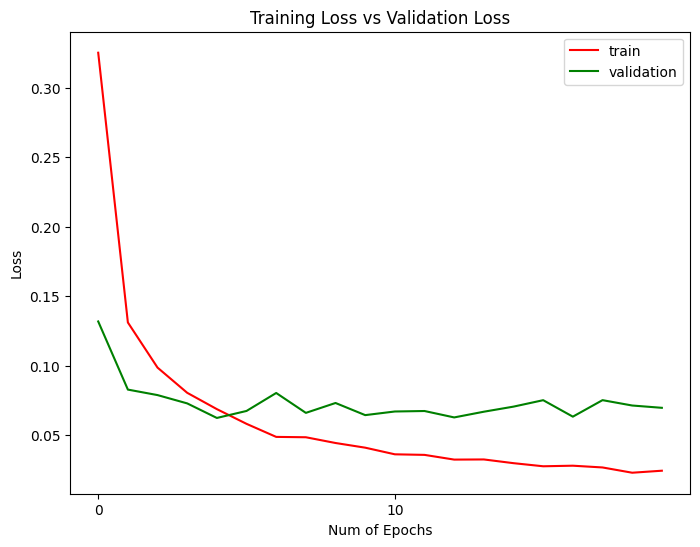

In [20]:
plt.figure(1, figsize=(8,6))
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'g')
plt.xticks(np.arange(0, n_epochs, 10.0))

plt.xlabel("Num of Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend(['train','validation'])
plt.show()



In [21]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.06962992250919342
Test accuracy: 0.9828000068664551


In [22]:

# evaluate loaded model
scores_train = model.evaluate(x_train, y_train, verbose=0)
scores_test  = model.evaluate(x_test,  y_test,  verbose=0)

print("Accuracy Train: %.2f%% , Test: %.2f%% " % (scores_train[1]*100, scores_test[1]*100 ))

Accuracy Train: 99.87% , Test: 98.28% 


In [65]:
# Confusion matrix result

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Y_pred = model.predict(x_test, verbose=2)

y_pred = np.argmax(Y_pred, axis=1)

#confusion matrix
cm = confusion_matrix(np.argmax(y_test,axis=1),y_pred)
print(cm)



157/157 - 2s - 15ms/step
[[864  21  69  30  16]
 [ 48 917  10  24   1]
 [ 76   2 746 110  66]
 [ 51  12 113 746  78]
 [ 33   3 100  75 789]]


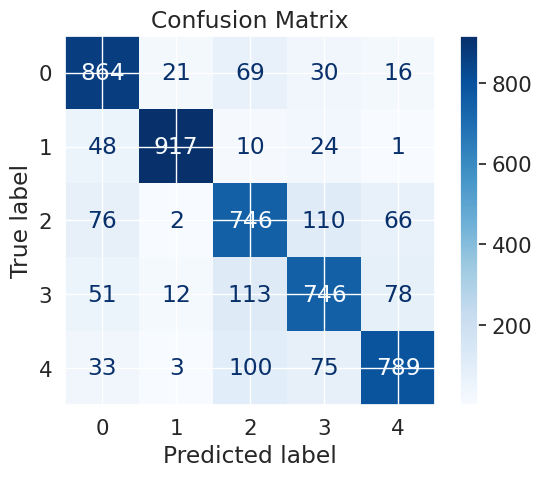

In [66]:
# Visualizing of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


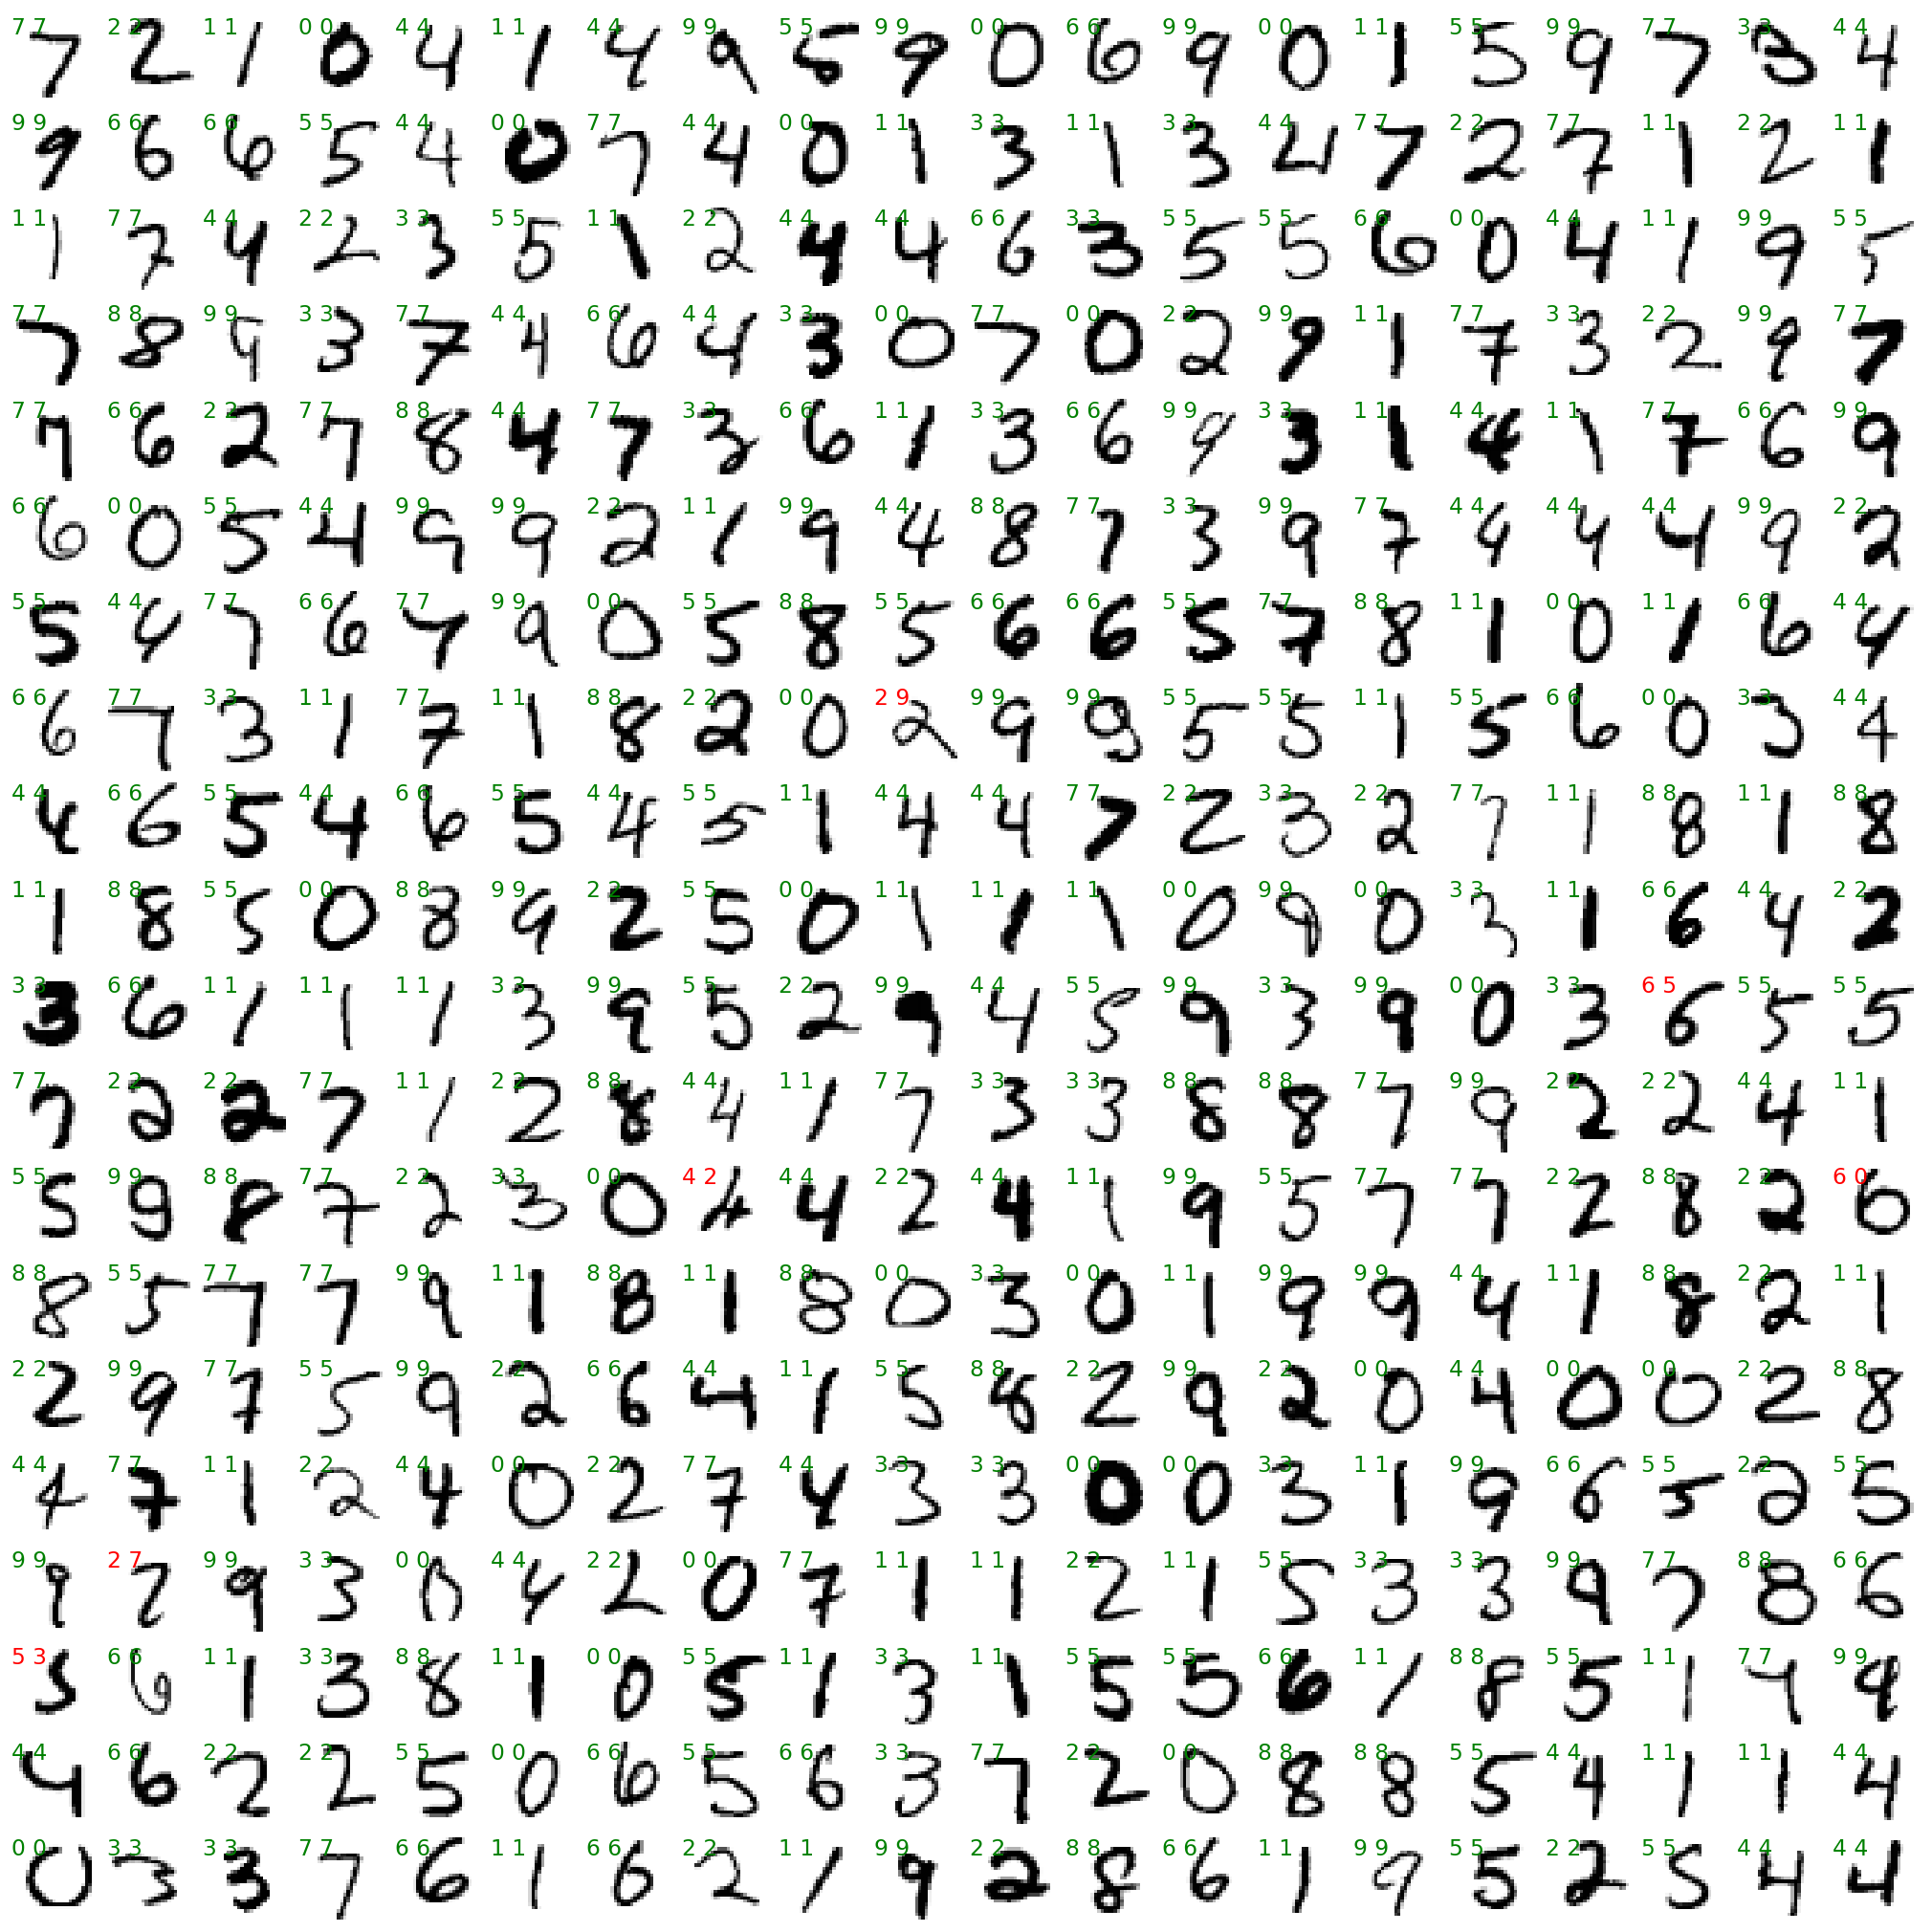

In [25]:
# use the model to predict the labels of the test data
predicted = model.predict(x_test)
expected = y_test0



# Plot the prediction
fig = plt.figure(figsize=(20, 20))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


# plot the digits: each image is 28x28 pixels
for i in range(400):
    ax = fig.add_subplot(20, 20, i + 1, xticks=[], yticks=[])
    ax.imshow(x_test[i].reshape(28,28), cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    if np.argmax(predicted[i]) == expected[i]:
        ax.text(0, 7, str(expected[i])+" "+str(np.argmax(predicted[i])), color='green')
    else:
        ax.text(0, 7, str(expected[i])+" "+str(np.argmax(predicted[i])), color='red')

# **Visualize the neural network**

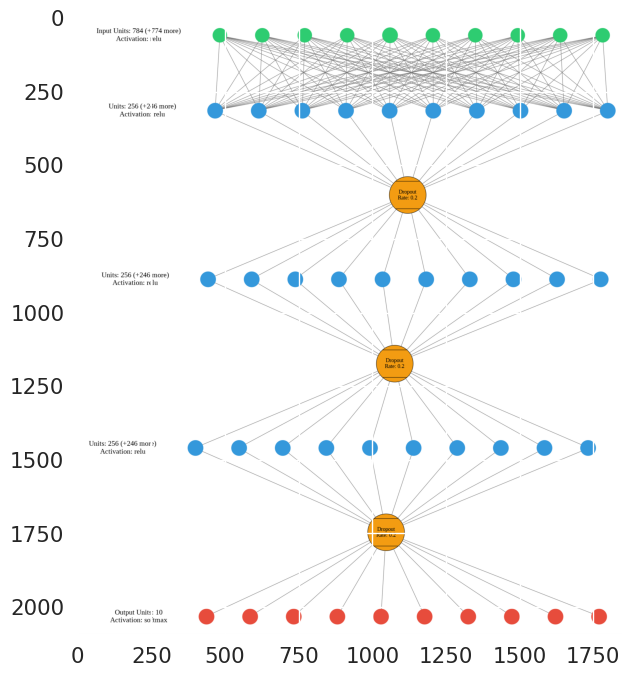

In [26]:

# Creates the graph.png file

! pip3 install keras-visualizer
from keras_visualizer import visualizer

#create the graph.png image
visualizer(model=model, file_name='graph', file_format='png')

#show the graph
from matplotlib.pyplot import figure
import matplotlib.image as mpimg

figure(figsize=(12, 8))
img = mpimg.imread('graph.png')
imgplot = plt.imshow(img,)
plt.show()

#<font color=green> **Summary**

* we have learned about neural networks, and ...
* <span style="color:#000000"> __...we have built our very first Deep Neural Network\!\!\!__ </span>



<mark> Exercise: try classification also with much smaller / bigger network</mark>



---



---



---



<center>

# <font color = "green"> **Convolutional Neural Networks (CNN)**

# <font color = "green"> - an excellent tool for image recognition

</center>



<span style="color:#800000"> __We have designed a net to identify__ </span>  <span style="color:#800000"> __hand\-written digits__ </span>

60000 train samples

10000 test samples

Model: "sequential"

Trainable params: 932\,362


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_74.png' width=450px>

__Digits - images 28 x 28   pixels__

<span style="color:#800000"> __Program results__ </span>


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_75.png' width=450px>

<br>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_76.png' width=450px>

**Test accuracy: 98.42%**

#<font color='red'>**Question:**
##<font color='red'>**Can we improve this result?**


#**Each layer is finding more and more complicated features**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture6/img27.png' width=650px>



##**An important remark:**

Each "feature detector" detects a feature only in a given place on picture. This means that to detect for example "a horizontal line" in any region of an image we need many independant horizontal line detectors each looking at different point in image.


#**Picture to vector**

<span style="color:#000000">At the beginning picture \(array of pixels\) is transformed to an input vector \(flattening\): </span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_714.png' width=450px>

Loss of information – neighbour pixels are no longer close together\.



#**Convolutional Neural Network Pattern recognition**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_715.png' width=450px>

<span style="color:#000000">Many connections… How to simplify the deep neural network?</span>

#**Convolutional NN**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_716.png' width=450px>

<span style="color:#000000">Just connect only local areas\, for example 10x10 pixels\. </span>

<span style="color:#000000">Huge reduction of the number of parameters\!</span>

<span style="color:#000000">The same features might be found in different places => so we could train many filters\, each recognizing another feature\, and move them over the picture\.</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_717.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_718.png' width=450px>



#**Pooling**

In pooling  (in most cases </span>  <span style="color:#000000"> __max pooling__ </span>  <span style="color:#000000">\) the group of outputs for a larger input area is replaced by a maximum \(or average\) for this given area:</span>

* <span style="color:#000000">Data reduction\,</span>
* <span style="color:#000000">Lower sensitivity for the position of a given feature\.</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_720.png' width=450px>



<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_719.png' width=450px>


#**Dropout**

<span style="color:#000000">Effective and most commonly used regularization technique for neural networks\, developed by Hinton and his students at the University of Toronto\. Dropout\, applied to a layer\, consists of randomly "dropping out" \(i\.e\. setting to zero\) a number of output features of the layer during training\.</span>

Geoff Hinton has said that he was inspired\, among other things\, by a fraud prevention mechanism used by banks \-\- in his own words:
<br>
 "*I went to my bank\. The tellers kept changing and I asked one of them why\. He said he didn’t know but they got moved around a lot\. I figured it must be because it would require cooperation between employees to successfully defraud the bank\. This made me realize that randomly removing a different subset of neurons on each example would prevent conspiracies and thus reduce overfitting"*\.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_721.png' width=450px>



#**Convolutional network - a winner of ILSVRC-2012 challenge**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_722.png' width=450px>




<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_723.png' width=450px>

<span style="color:#000000">(\*) *SIFT \- scale\-invariant feature transform\, algorithm published in 1999 roku by David Lowe\.</span>*



<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_724.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_725.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_726.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_727.png' width=450px>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_728.png' width=450px>



<span style="color:#800000"> __Few properties of Deep Neural Networks__ </span>

Have a look at: <br>
*http://www.deeplearningbook.org*

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_729.png' width=450px>

<br>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_730.png' width=450px>




#**Nice blog entry about convolutional neural networks:**

https://towardsdatascience.com/convolutional-neural-networks-explained-9cc5188c4939

<img src='https://miro.medium.com/max/1400/1*kkyW7BR5FZJq4_oBTx3OPQ.png' width=650px>

#**Program demonstrating how the features in CNN are recognized**

https://adamharley.com/nn_vis/


<img src='https://adamharley.com/images/vis10.gif' width=450px>




#**Back to our digits recognition with CNN…**




In [27]:
'''Trains a simple deep NN on the MNIST dataset.

Gets to 99.6% test accuracy after 40 epochs
(there is *a lot* of margin for parameter tuning).
2 seconds per epoch on a K520 GPU.
'''

from __future__ import print_function

import matplotlib.pyplot as plt
import numpy as np

import keras
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import RMSprop, Adam

from keras.utils import plot_model
from IPython.display import Image

batch_size = 128
num_classes = 10
epochs = 20

# input image dimensions
img_rows, img_cols = 28, 28

# the data, split between train and test sets
(x_train, y_train0), (x_test, y_test0) = mnist.load_data()

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train0, num_classes)
y_test = tf.keras.utils.to_categorical(y_test0, num_classes)




60000 train samples
10000 test samples


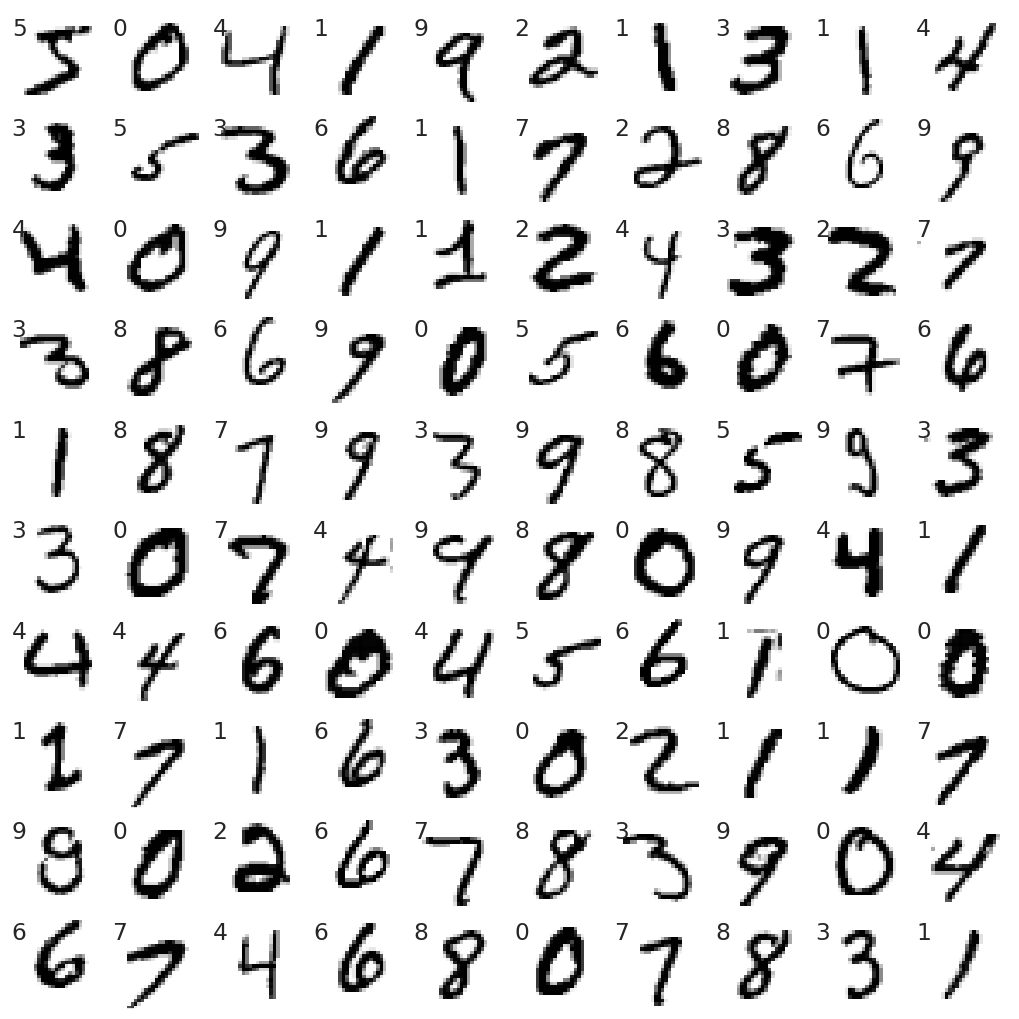

In [28]:
#visualize the digits

fig = plt.figure(figsize=(10, 10))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(100):
    ax = fig.add_subplot(10, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(x_train[i].reshape(img_rows, img_cols), cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 7, str(y_train0[i]))

In [29]:
# This is new as well

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

###**Here is the only place where we change something:**
we replace *Dense* layers by convolutional ones:

In [30]:
# Our old fully connected (dense) network
#model = Sequential()
#model.add(Dense(512, activation='relu', input_shape=(784,)))
#model.add(Dropout(0.2))
#model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
#model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.2))
#model.add(Dense(num_classes, activation='softmax'))

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))



model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,162 (879.54 KB)

 Trainable params: 225,162 (879.54 KB)

 Non-trainable params: 0 (0.00 B)

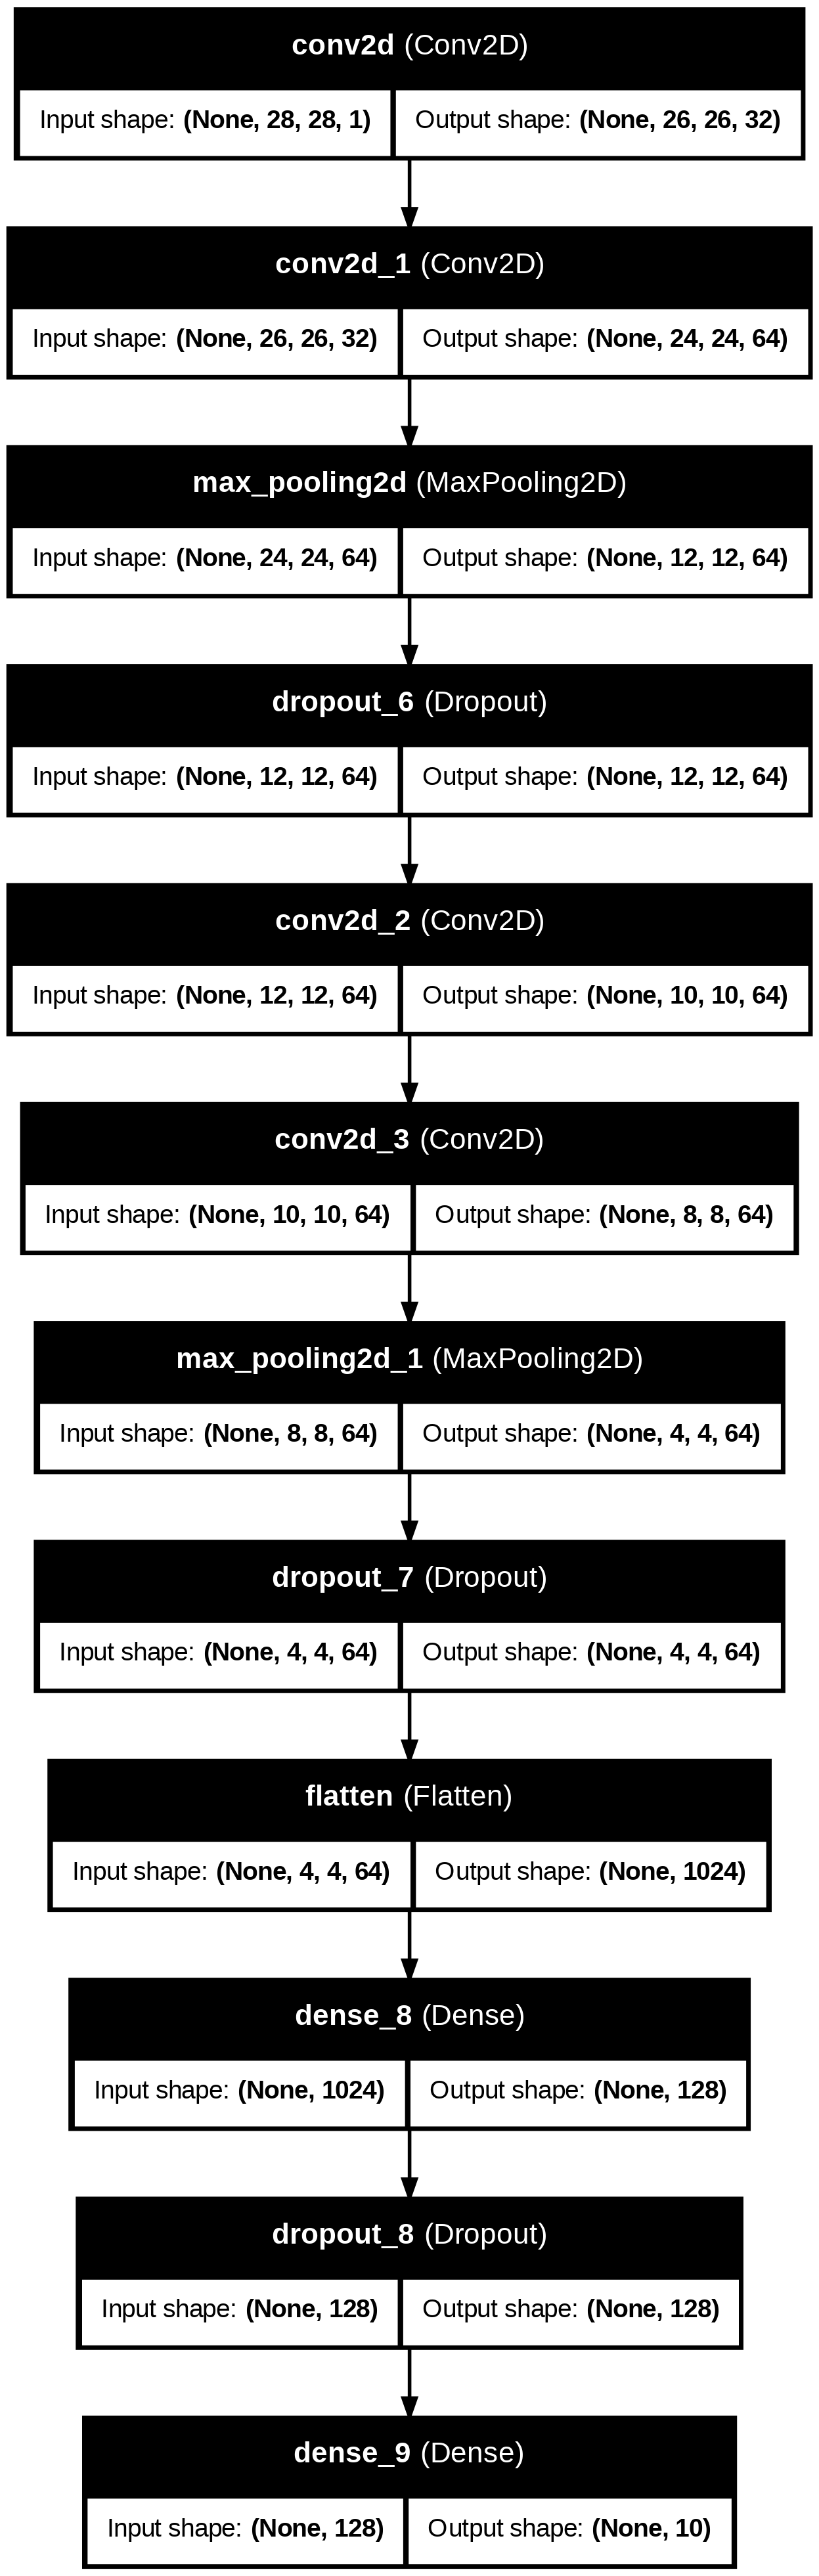

In [31]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
Image('model_plot.png')

In [32]:
model.compile(loss='categorical_crossentropy',
              optimizer="adam",
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.9061 - loss: 0.2919 - val_accuracy: 0.9845 - val_loss: 0.0461
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9756 - loss: 0.0847 - val_accuracy: 0.9873 - val_loss: 0.0351
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9815 - loss: 0.0603 - val_accuracy: 0.9907 - val_loss: 0.0269
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9852 - loss: 0.0493 - val_accuracy: 0.9927 - val_loss: 0.0229
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9879 - loss: 0.0422 - val_accuracy: 0.9932 - val_loss: 0.0188
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9883 - loss: 0.0393 - val_accuracy: 0.9943 - val_loss: 0.0174
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9897 - loss: 0.0342 - val_accuracy: 0.9938 - val_loss: 0.0192
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9904 - loss: 0.0327 - val_accuracy: 

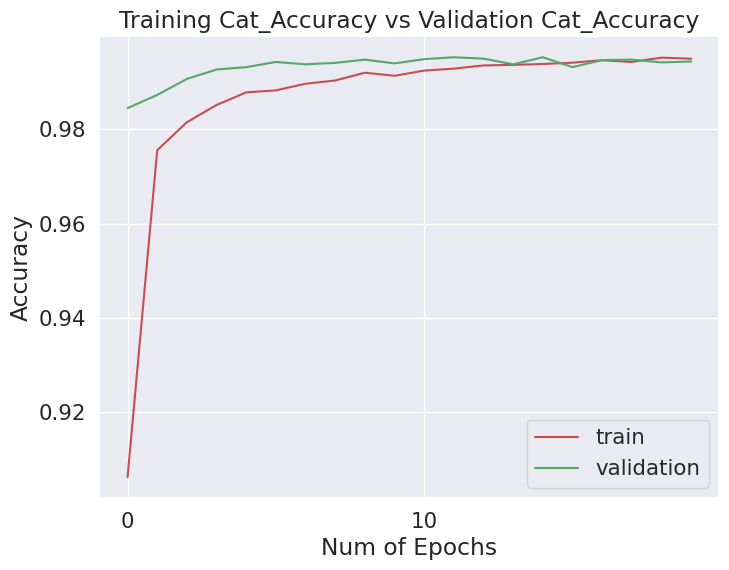

In [33]:
# Plots for training and testing process: loss and accuracy

n_epochs = len(history.history['loss'])

plt.figure(0, figsize=(8, 6))
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'g')
plt.xticks(np.arange(0, n_epochs, 10.0))

plt.xlabel("Num of Epochs")
plt.ylabel("Accuracy")
plt.title("Training Cat_Accuracy vs Validation Cat_Accuracy")
plt.legend(['train','validation'])




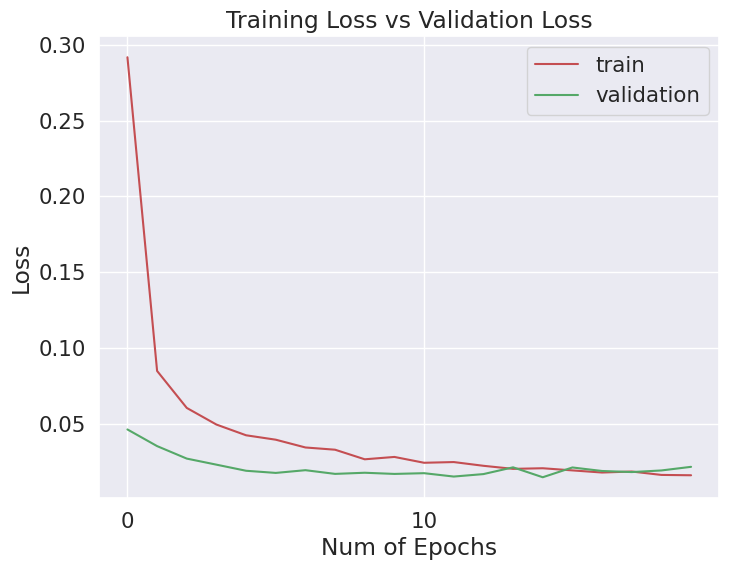

In [34]:
plt.figure(1, figsize=(8, 6))
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'g')
plt.xticks(np.arange(0, n_epochs, 10.0))

plt.xlabel("Num of Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend(['train','validation'])
plt.show()


In [35]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.021419217810034752
Test accuracy: 0.9944000244140625


In [36]:

# evaluate loaded model
scores_train = model.evaluate(x_train, y_train, verbose=0)
scores_test  = model.evaluate(x_test,  y_test,  verbose=0)

print("Accuracy Train: %.2f%% , Test: %.2f%% " % (scores_train[1]*100, scores_test[1]*100 ))

Accuracy Train: 99.88% , Test: 99.44% 


In [37]:
# Confusion matrix result

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
Y_pred = model.predict(x_test, verbose=0)

y_pred = np.argmax(Y_pred, axis=1)

y_test2 = np.argmax(y_test, axis=1)



#confusion matrix
cm = confusion_matrix(np.argmax(y_test,axis=1),y_pred)
print(cm)



[[ 977    2    0    0    0    0    0    1    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   1    1 1027    0    0    0    0    3    0    0]
 [   0    0    1 1005    0    3    0    1    0    0]
 [   0    0    0    0  981    0    1    0    0    0]
 [   0    0    0    4    0  886    1    1    0    0]
 [   2    2    0    0    1    1  950    0    2    0]
 [   0    5    3    0    0    0    0 1020    0    0]
 [   1    0    1    1    0    0    0    0  970    1]
 [   0    0    0    0   11    1    0    4    0  993]]


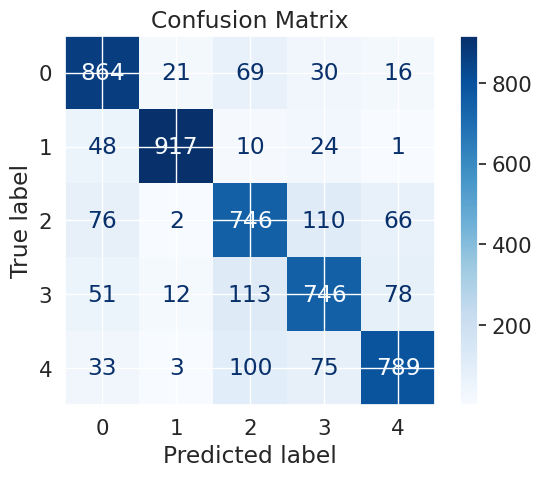

In [67]:
# Visualizing of confusion matrix
# Visualizing of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


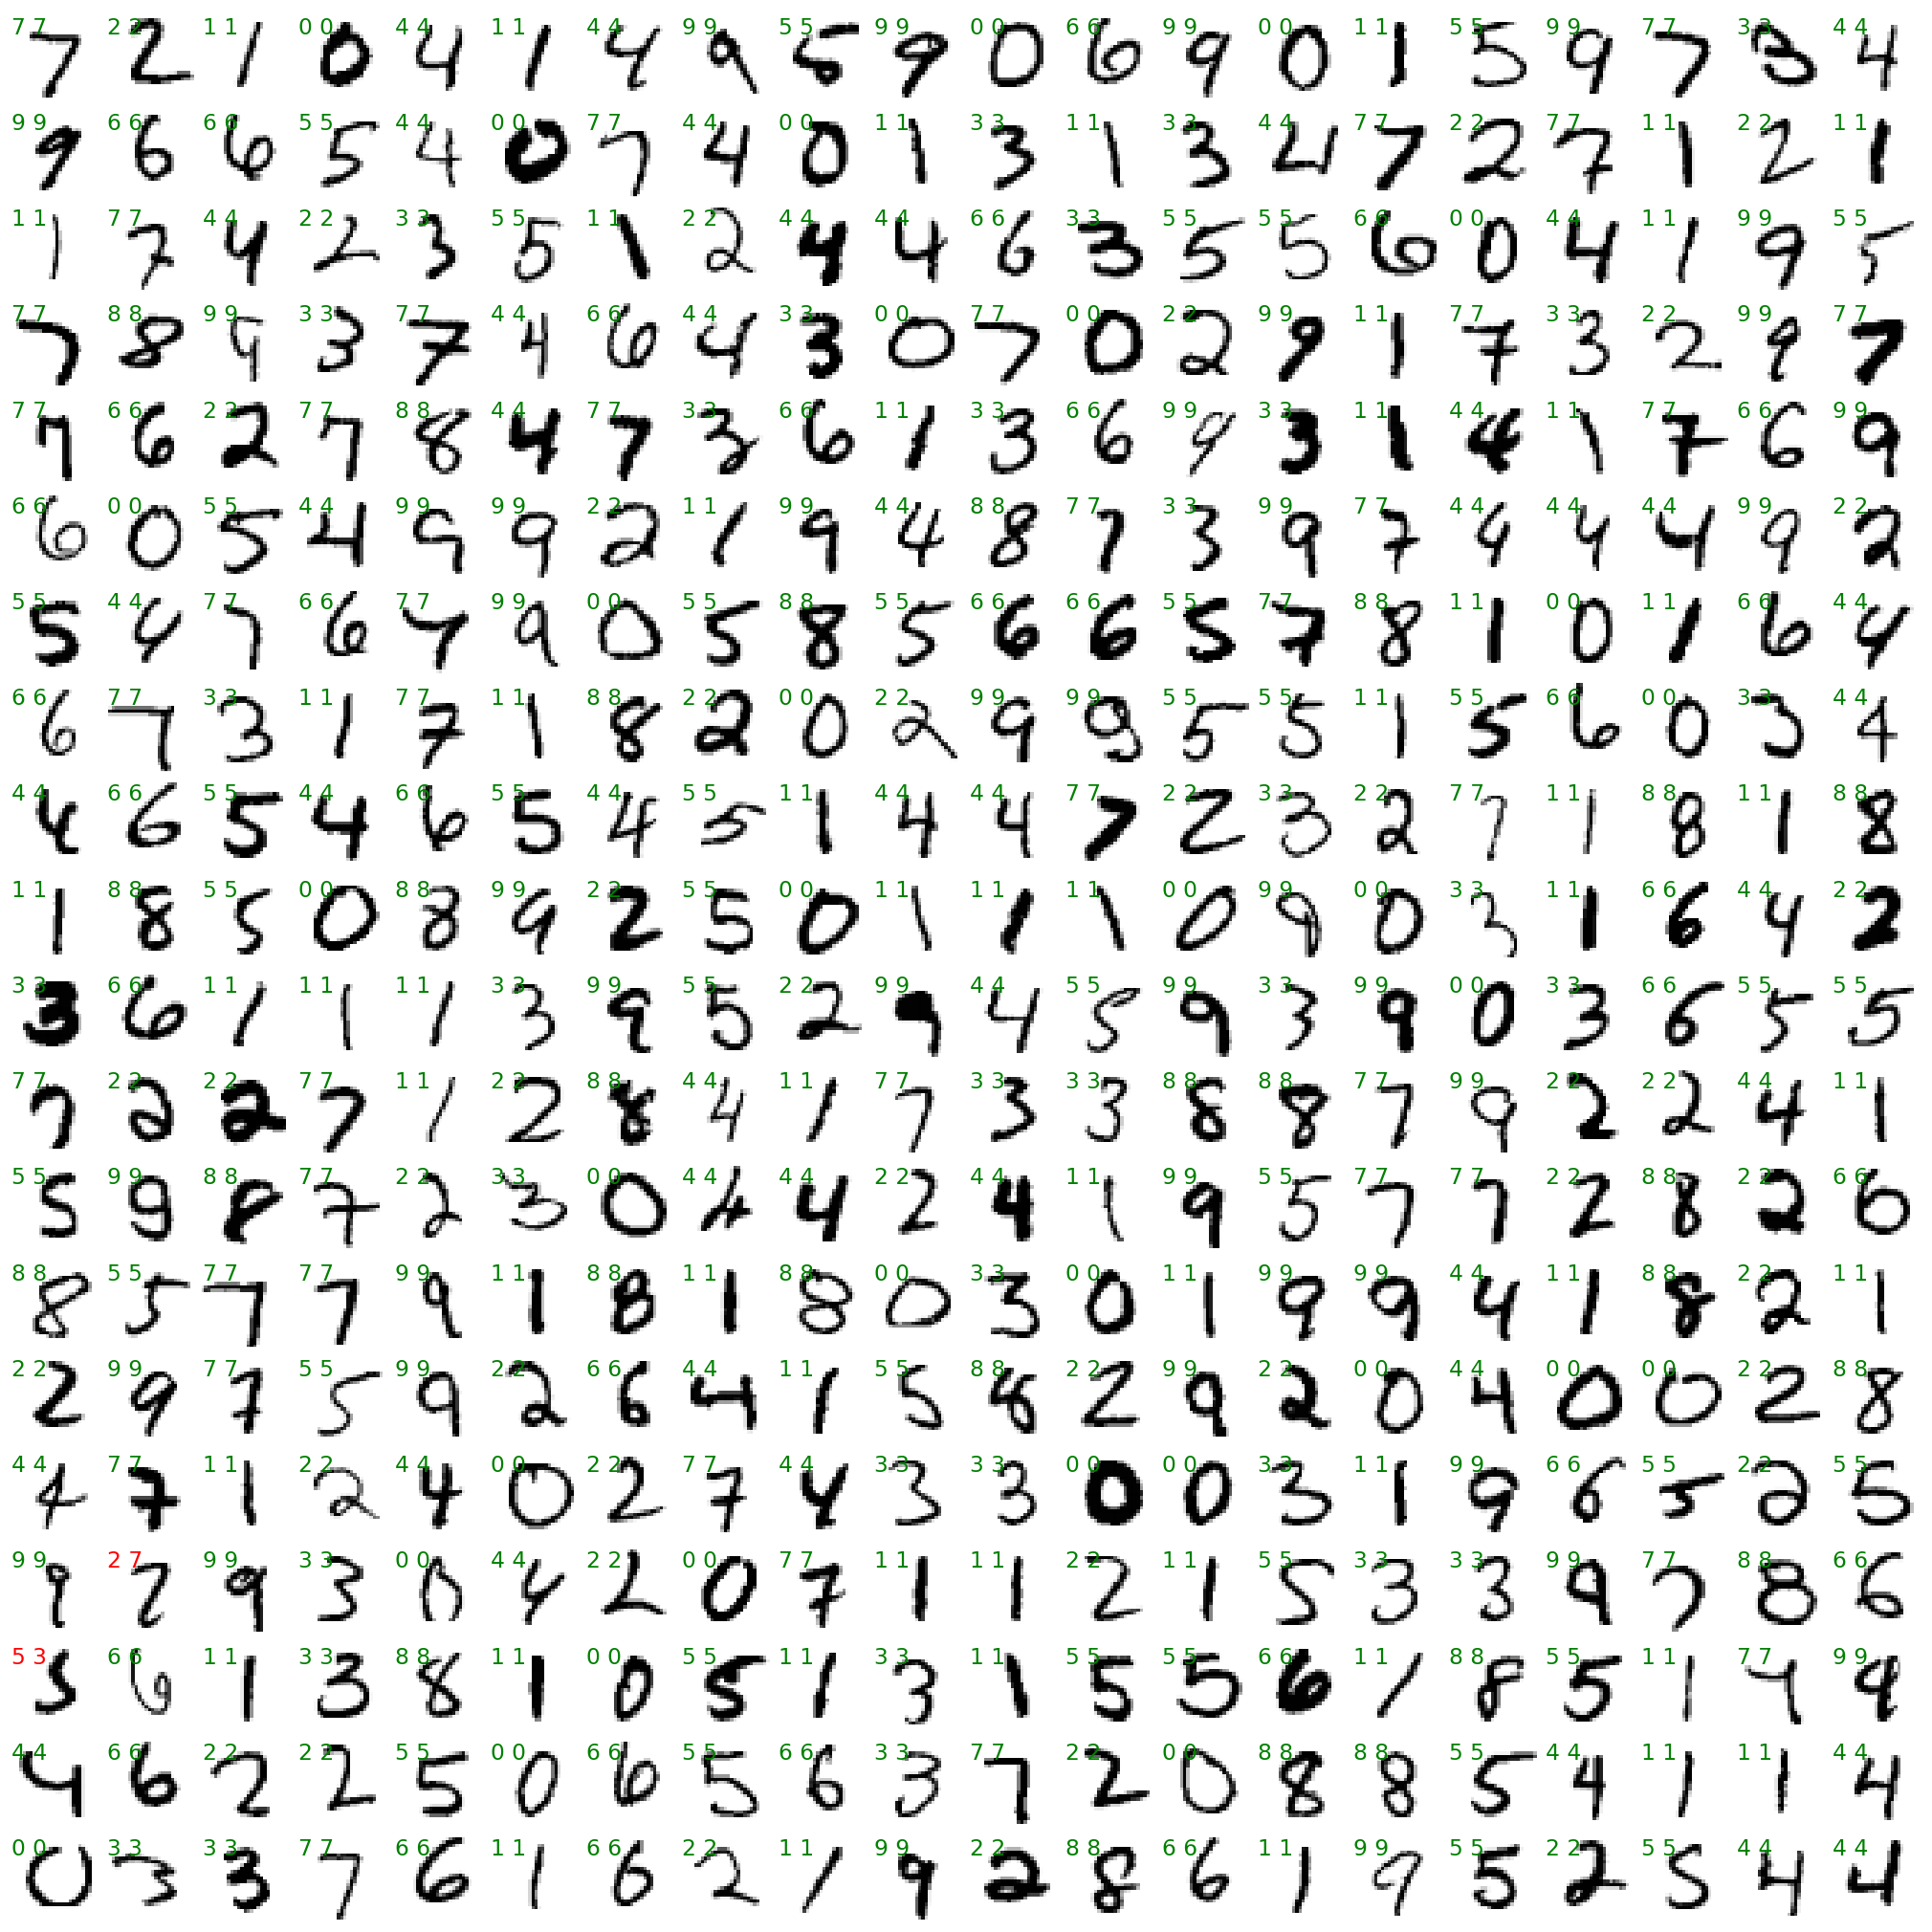

In [39]:
# use the model to predict the labels of the test data
predicted = model.predict(x_test)
expected = y_test0



# Plot the prediction
fig = plt.figure(figsize=(20, 20))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


# plot the digits: each image is 28x28 pixels
for i in range(400):
    ax = fig.add_subplot(20, 20, i + 1, xticks=[], yticks=[])
    ax.imshow(x_test[i].reshape(img_rows, img_cols), cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    if np.argmax(predicted[i]) == expected[i]:
        ax.text(0, 7, str(expected[i])+" "+str(np.argmax(predicted[i])), color='green')
    else:
        ax.text(0, 7, str(expected[i])+" "+str(np.argmax(predicted[i])), color='red')

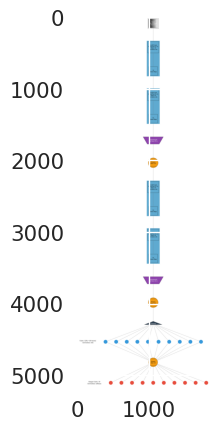

In [40]:
# Creates the graph.png file

! pip3 install keras-visualizer
from keras_visualizer import visualizer

#create the graph.png image
visualizer(model=model, view=False, file_format='png', file_name='graph')

#show the graph
import matplotlib.image as mpimg
img = mpimg.imread('graph.png')
imgplot = plt.imshow(img,)
plt.show()


#**We are getting much\, much better results\! Think why?**



* Test loss:     0\.0160
* **Test accuracy: 99.45%** (actual result varies)

#**Is it possible to make it even better?**

* Train more networks in parallel and take an average as a classifier,
* Artificially increase the size of the training dataset - create more images by the *augmentation* procedure (next lecture).




---



---



---



#**State of the art code for hand-written digits recognition**

* 15 convolutional neural networks working in parallel
* image augmentation

Detailed description and code:

https://www.kaggle.com/cdeotte/25-million-images-0-99757-mnist

###**Augmentation:**

Artificially increase the number of training events by some modifications like: rotation, translation, shift etc.

```
# CREATE MORE IMAGES VIA DATA AUGMENTATION
datagen = ImageDataGenerator(
        rotation_range=10,  
        zoom_range = 0.10,  
        width_shift_range=0.1,
        height_shift_range=0.1)
```
<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/__results___8_0.png' width=650px>



###**15 Convolutional neural networks with advanced architecture:**

The CNNs in this kernel follow [LeNet5's](https://hal.science/hal-03926082/document) design (pictured below) with the following improvements:

* Two stacked 3x3 filters replace the single 5x5 filters. These become nonlinear 5x5 convolutions
* A convolution with stride 2 replaces pooling layers. These become learnable pooling layers.
* ReLU activation replaces sigmoid.
* Batch normalization is added
* Dropout is added
* More feature maps (channels) are added
* **An ensemble of 15 CNNs with bagging is used**


<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/LeNet5.png' width=650px>


#**Performance:**

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/histBoth5.png' width=650px>




---



---



---



<mark> Exercise: try much smaller network, try to remove Dropout and MaxPooling layers. What happens? Try reducing number of Conv2d layers and number of filters.</mark>

# <font color = green> **Propositions for further learning**

##**A Deep Neural Network Applet**

Nice applet showing the performance of deep NN:

http://cs.stanford.edu/people/karpathy/convnetjs/

**Have fun playing!**

<mark> **Exercises:** </mark>
1.   <mark>Fully connected network:
   - <mark>try different Dropout values or skip dropout at all,
   - <mark>try different activation functions and different number of nodes in the hidden layers,
2.   <mark>Convolutional network:
    - <mark>try much smaller network, try to remove Dropout and MaxPooling layers,
    - <mark>try reducing number of Conv2d layers and number of filters. What happens?





---



---



---




<center>

# <font color='green'> **Data augmentation**

#**How to improve the performance?**

From last week example we have learned, that the methods are:
* Train more networks in parallel and take an average as a classifier,
* Artificially increase the size of the training dataset - <font color='red'> **create more images by the *augmentation* procedure.**


#**Data augmentation**
in data analysis are techniques used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data from existing data. It acts as a regularizer and helps reduce overfitting when training a machine learning model.

###**Transformations of images**

Geometric transformations, flipping, color modification, cropping, rotation, noise injection and random erasing are used to augment image in deep learning.

###**Introducing new synthetic images**
If a dataset is very small, then a version augmented with rotation and mirroring etc. may still not be enough for a given problem. Another solution is the sourcing of entirely new, synthetic images through various techniques, for example the use of **generative adversarial networks** *(we will talk about them later)* to create new synthetic images for data augmentation.

<br>

*Shorten, Connor; Khoshgoftaar, Taghi M. (2019). "[A survey on Image Data Augmentation for Deep Learning](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-019-0197-0)". Mathematics and Computers in Simulation. springer. 6: 60. doi:10.1186/s40537-019-0197-0*

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/data_aug_basic.png' width=650px>

<br>

---

<br>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/1_kqKzGryy0qYjEXbR3kyNOg.png' width=650px>




---



---



---




# <font color='green'>**An example – pattern recognition**
# <font color='green'>**on CIFAR10 photos dataset**

**CIFAR10** small image classification. <br>Dataset of 50\,000 32x32 color training images\, labeled over 10 categories\, and 10\,000 test images\.</span>

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_733.png' width=450px>



**Augmentation:**<br>
the network is trained with and without augmentation.

<img src='https://raw.githubusercontent.com/marcinwolter/Machine-learning-KISD-2022/main/images/lecture7/MachineLearning2020_734.png' width=450px>






# Modified version of:
https://github.com/moritzhambach/Image-Augmentation-in-Keras-CIFAR-10-/blob/master/CNN%20with%20Image%20Augmentation%20(CIFAR10).ipynb



### CNN with Image Augmentation (CIFAR10)
images of 10 categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. In RGB, 32x32 pixels.

**The state of the art accuracy is about 99 percent.**

We will NOT reach such a high accuracy...


In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras as k
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from keras.regularizers import l2
import h5py
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

### **Important:** we reduce number or training images taking 5 classes out of 10 and reducing the size of training dataset

This is done to make the training faster. You can try training un the full dataset.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


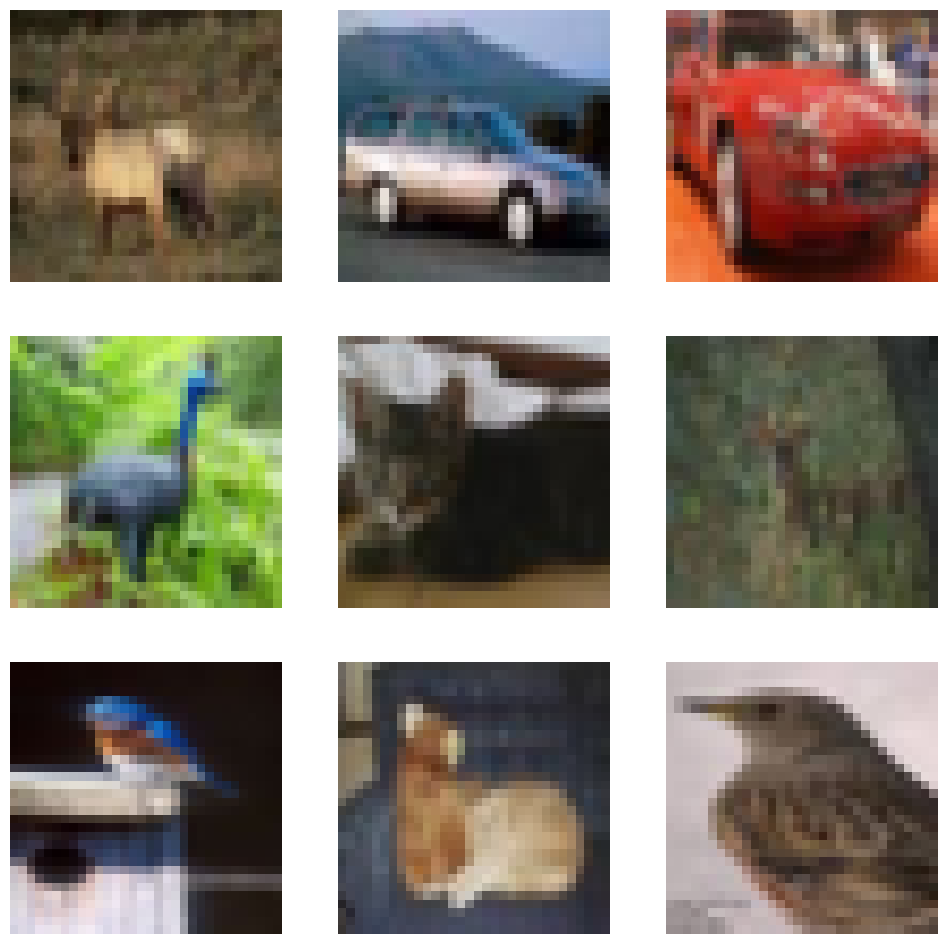

In [42]:
 # labels
num_classes=5

#load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
img_rows, img_cols , channels = 32,32,3

# REDUCE THE SIZE OF TRAINING SAMPLE TO 30 000 events
x_train = x_train[0:30000]
y_train = y_train[0:30000]

# take some labels only
x_train = x_train[np.where(y_train.reshape(-1)<num_classes)]
y_train = y_train[np.where(y_train.reshape(-1)<num_classes)]
x_test = x_test[np.where(y_test.reshape(-1)<num_classes)]
y_test = y_test[np.where(y_test.reshape(-1)<num_classes)]

# save x_test images
xx_test = x_test
yy_test = y_test

fig = plt.figure(figsize=(12, 12))
for i in range(0,9):
    plt.subplot(330 + 1 + i)
    plt.axis('off')
    plt.imshow(x_train[i])
plt.show()

In [43]:
#reshape into images
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channels)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, channels)
input_shape = (img_rows, img_cols, channels)
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (15020, 32, 32, 3)
15020 train samples
5000 test samples


In [44]:
#convert integers to float; normalise and center the mean
x_train=x_train.astype("float32")
x_test=x_test.astype("float32")
mean=np.mean(x_train)
std=np.std(x_train)
x_test=(x_test-mean)/std
x_train=(x_train-mean)/std

In [45]:

print(y_train.shape)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test, num_classes)
print(y_train.shape)

(15020, 1)
(15020, 5)


In [46]:
# build and compile the model


reg=None
num_filters=32
ac='relu'
#adm=tf.keras.optimizers.legacy.Adam(learning_rate=0.001, decay=0, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
# Use the standard Adam optimizer from keras.optimizers:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)

drop_dense=0.5
drop_conv=0.1

model = Sequential()

model.add(Conv2D(num_filters, (3, 3), activation=ac, kernel_regularizer=reg, input_shape=input_shape,padding='same'))
model.add(BatchNormalization(axis=-1))
model.add(Conv2D(num_filters, (3, 3), activation=ac,kernel_regularizer=reg,padding='same'))
model.add(BatchNormalization(axis=-1))
model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 16x16x3xnum_filters
model.add(Dropout(drop_conv))

model.add(Conv2D(2*num_filters, (3, 3), activation=ac,kernel_regularizer=reg,padding='same'))
model.add(BatchNormalization(axis=-1))
model.add(Conv2D(2*num_filters, (3, 3), activation=ac,kernel_regularizer=reg,padding='same'))
model.add(BatchNormalization(axis=-1))
model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 8x8x3x(2*num_filters)
model.add(Dropout(drop_conv))

model.add(Conv2D(4*num_filters, (3, 3), activation=ac,kernel_regularizer=reg,padding='same'))
model.add(BatchNormalization(axis=-1))
model.add(Conv2D(4*num_filters, (3, 3), activation=ac,kernel_regularizer=reg,padding='same'))
model.add(BatchNormalization(axis=-1))
model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 4x4x3x(4*num_filters)
model.add(Dropout(drop_conv))

model.add(Flatten())
model.add(Dense(512, activation=ac,kernel_regularizer=reg))
model.add(BatchNormalization())
model.add(Dropout(drop_dense))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer=opt)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,342,501 (5.12 MB)

 Trainable params: 1,340,581 (5.11 MB)

 Non-trainable params: 1,920 (7.50 KB)

#**Training without augmentation**

In [48]:

# training without augmentation
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=10,             # stop after 10 epochs of no improvement
    restore_best_weights=True  # roll back to the best epoch's weights
)


history=model.fit(x_train, y_train, batch_size=128, epochs=100, validation_data=(x_test, y_test), callbacks=[early_stop] )

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 39s 129ms/step - accuracy: 0.5661 - loss: 1.2771 - val_accuracy: 0.2012 - val_loss: 2.5438
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6832 - loss: 0.8389 - val_accuracy: 0.3748 - val_loss: 1.9400
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7379 - loss: 0.6958 - val_accuracy: 0.6114 - val_loss: 1.0269
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7755 - loss: 0.5884 - val_accuracy: 0.7648 - val_loss: 0.6296
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8071 - loss: 0.5146 - val_accuracy: 0.7832 - val_loss: 0.5786
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8306 - loss: 0.4507 - val_accuracy: 0.7880 - val_loss: 0.5812
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8565 - loss: 0.3794 - val_accuracy: 0.7998 - val_loss: 0.5392
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8691 - loss: 0.3528 

In [49]:
#training and test accuracy without dropout
train_acc=model.evaluate(x_train,y_train,batch_size=128)
train_acc

test_acc=model.evaluate(x_test,y_test,batch_size=128)
test_acc

print("Training accuracy: ", train_acc[1])
print("Testing accuracy: ", test_acc[1])

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9425 - loss: 0.1753
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8124 - loss: 0.5274
Training accuracy:  0.9424766898155212
Testing accuracy:  0.8123999834060669


In [50]:
# plotting helper function
def plothist(hist):
    plt.plot(hist.history['accuracy'])
    plt.plot(hist.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

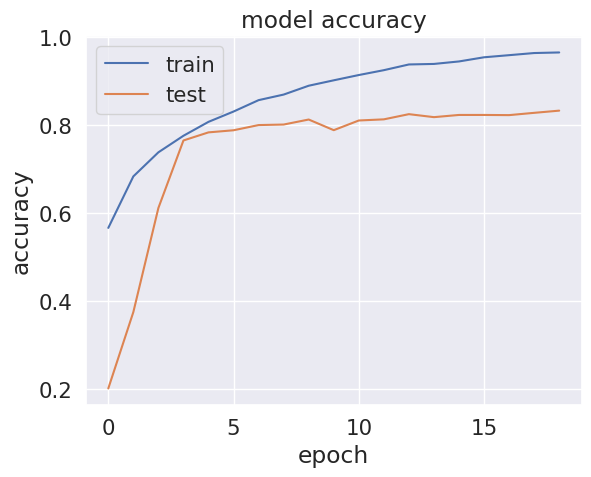

In [51]:
plothist(history)

In [52]:
#model.save('cifar10_01.h5')
#model=load_model('cifar10_01.h5')

#**Build bigger network, train with augmentation!**

# **Here comes the augmentation**

In [53]:
# set up image augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.25
    )
datagen.fit(x_train)

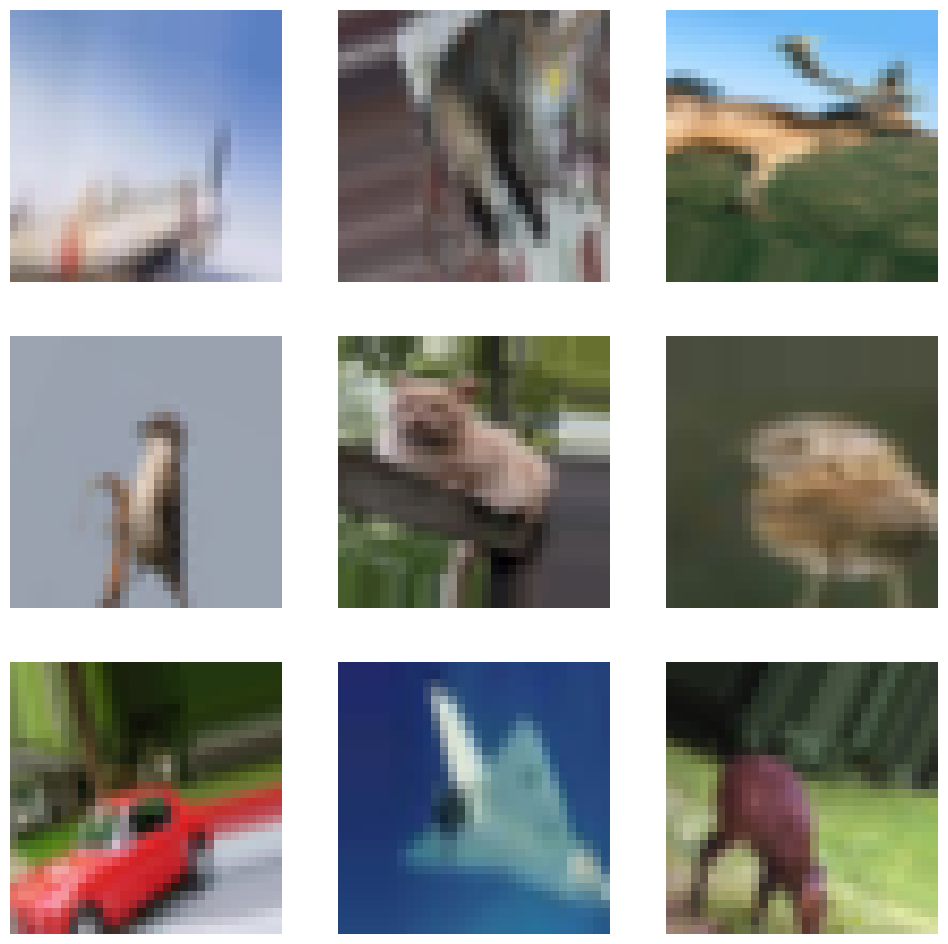

In [54]:
# see example augmentation images
fig = plt.figure(figsize=(12, 12))
for X_batch, y_batch in datagen.flow(x_train, y_train, batch_size=9):
    for i in range(0, 9):
         plt.subplot(330 + 1 + i)
         plt.imshow((X_batch[i]*std+mean).astype(np.uint8))    # again convert beack to integers
         plt.axis('off')
    plt.show()
    break



Augmentation of a single image

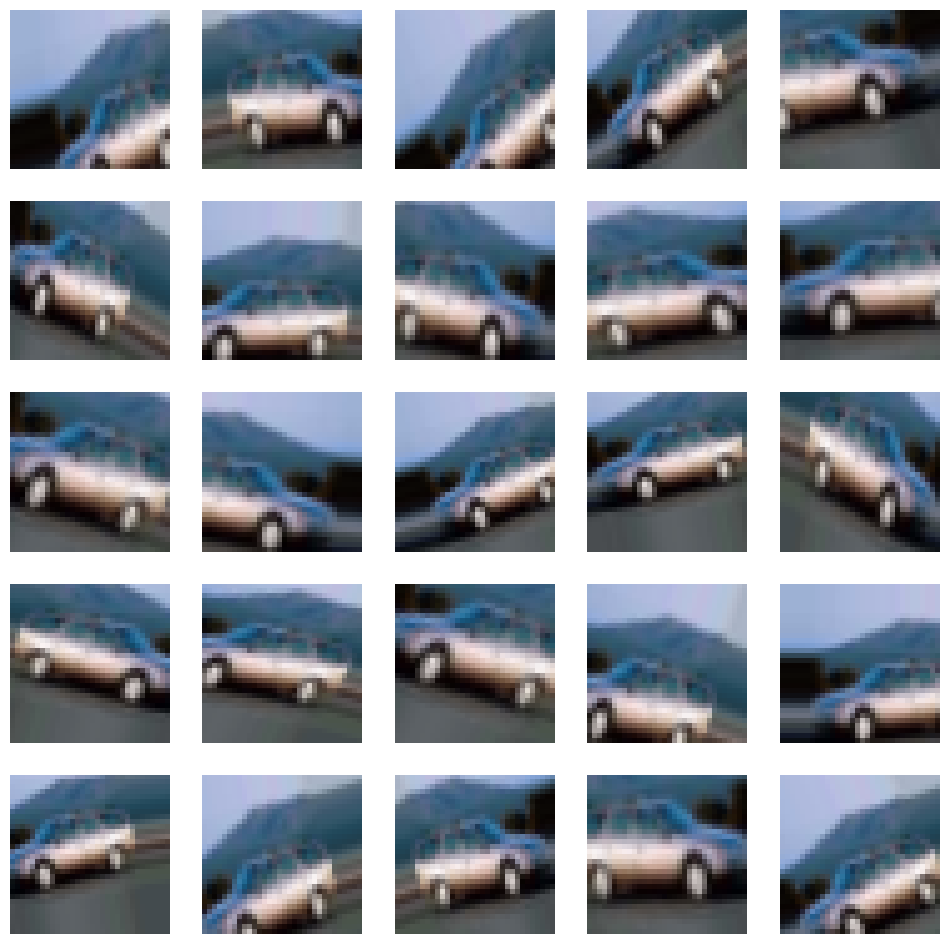

In [55]:
# see example augmentation images
fig = plt.figure(figsize=(12, 12))

for i in range(0, 25):
    for X_batch, y_batch in datagen.flow(x_train[1:3], y_train[1:3], batch_size=1, shuffle=False):
         plt.subplot(5,5,i+1)
         plt.imshow((X_batch[0]*std+mean).astype(np.uint8))
         plt.axis('off')
         break

plt.show()



In [56]:
# build again, same model as model1

#reg=l2(1e-4)   # L2 or "ridge" regularisation
reg2=None
num_filters2=32
ac2='relu'
# Use the standard Adam optimizer from keras.optimizers:
from tensorflow.keras.optimizers import Adam

opt2 = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)

drop_dense2=0.5
drop_conv2=0.1

model2 = Sequential()

model2.add(Conv2D(num_filters2, (3, 3), activation=ac2, kernel_regularizer=reg2, input_shape=(img_rows, img_cols, channels),padding='same'))
model2.add(BatchNormalization(axis=-1))
model2.add(Conv2D(num_filters2, (3, 3), activation=ac2,kernel_regularizer=reg2,padding='same'))
model2.add(BatchNormalization(axis=-1))
model2.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 16x16x3xnum_filters
model2.add(Dropout(drop_conv2))

model2.add(Conv2D(2*num_filters2, (3, 3), activation=ac2,kernel_regularizer=reg2,padding='same'))
model2.add(BatchNormalization(axis=-1))
model2.add(Conv2D(2*num_filters2, (3, 3), activation=ac2,kernel_regularizer=reg2,padding='same'))
model2.add(BatchNormalization(axis=-1))
model2.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 8x8x3x(2*num_filters)
model2.add(Dropout(drop_conv2))

model2.add(Conv2D(4*num_filters2, (3, 3), activation=ac2,kernel_regularizer=reg2,padding='same'))
model2.add(BatchNormalization(axis=-1))
model2.add(Conv2D(4*num_filters2, (3, 3), activation=ac2,kernel_regularizer=reg2,padding='same'))
model2.add(BatchNormalization(axis=-1))
model2.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 4x4x3x(4*num_filters)
model2.add(Dropout(drop_conv2))

model2.add(Flatten())
model2.add(Dense(512, activation=ac2,kernel_regularizer=reg2))
model2.add(BatchNormalization())
model2.add(Dropout(drop_dense2))
model2.add(Dense(num_classes, activation='softmax'))

model2.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer=opt2)

In [57]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,342,501 (5.12 MB)

 Trainable params: 1,340,581 (5.11 MB)

 Non-trainable params: 1,920 (7.50 KB)

#**Training with augmentation (using *datagen.flow*)**

In [58]:
# train with image augmentation
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=10,             # stop after 10 epochs of no improvement
    restore_best_weights=True  # roll back to the best epoch's weights
)

history2=model2.fit(datagen.flow(x_train, y_train, batch_size=128),
                    steps_per_epoch = int(len(x_train) / 128), epochs=100, validation_data=(x_test, y_test),
                    callbacks=[early_stop])

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.4611 - loss: 1.5984 - val_accuracy: 0.2004 - val_loss: 2.7609
Epoch 2/100
  1/117 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5312 - loss: 1.1286

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5312 - loss: 1.1286 - val_accuracy: 0.2004 - val_loss: 2.7684
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.5589 - loss: 1.1579 - val_accuracy: 0.2674 - val_loss: 2.1411
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6250 - loss: 1.0022 - val_accuracy: 0.2724 - val_loss: 2.1374
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.6007 - loss: 1.0253 - val_accuracy: 0.5320 - val_loss: 1.2327
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6172 - loss: 0.9345 - val_accuracy: 0.5462 - val_loss: 1.1795
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.6341 - loss: 0.9427 - val_accuracy: 0.7022 - val_loss: 0.7614
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6484 - loss: 1.0424 - val_accuracy: 0.7024 - val_loss: 0.7546
Epoch 9/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.6590 - loss: 0.8809 - val_accurac

In [59]:
#model2.save('cifar10_02.h5')         # about 90% accuracy

In [60]:
#training and test accuracy without dropout
train_acc=model2.evaluate(x_train,y_train,batch_size=128)
train_acc

test_acc=model2.evaluate(x_test,y_test,batch_size=128)
test_acc

print("Training accuracy: ", train_acc[1])
print("Testing accuracy: ", test_acc[1])

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8750 - loss: 0.3492
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8526 - loss: 0.4152
Training accuracy:  0.8750332593917847
Testing accuracy:  0.8525999784469604


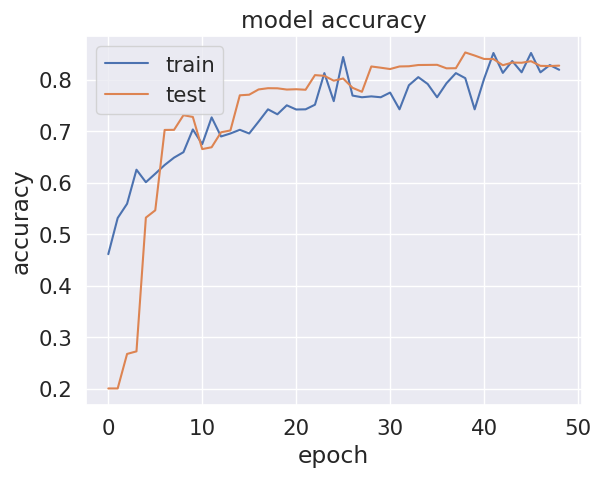

In [61]:
plothist(history2)  # 128 batch, 0.001 lr,

# **Plot images**

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/tmp/ipykernel_1600/2843180054.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(0, -2, class_names[int(yy_test[i_img])], color='green', fontsize=12)
/tmp/ipykernel_1600/2843180054.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(0, -2, class_names[int(yy_test[i_img])]+" "+class_names[y_pred[i_img]], color='red', fontsize=12)


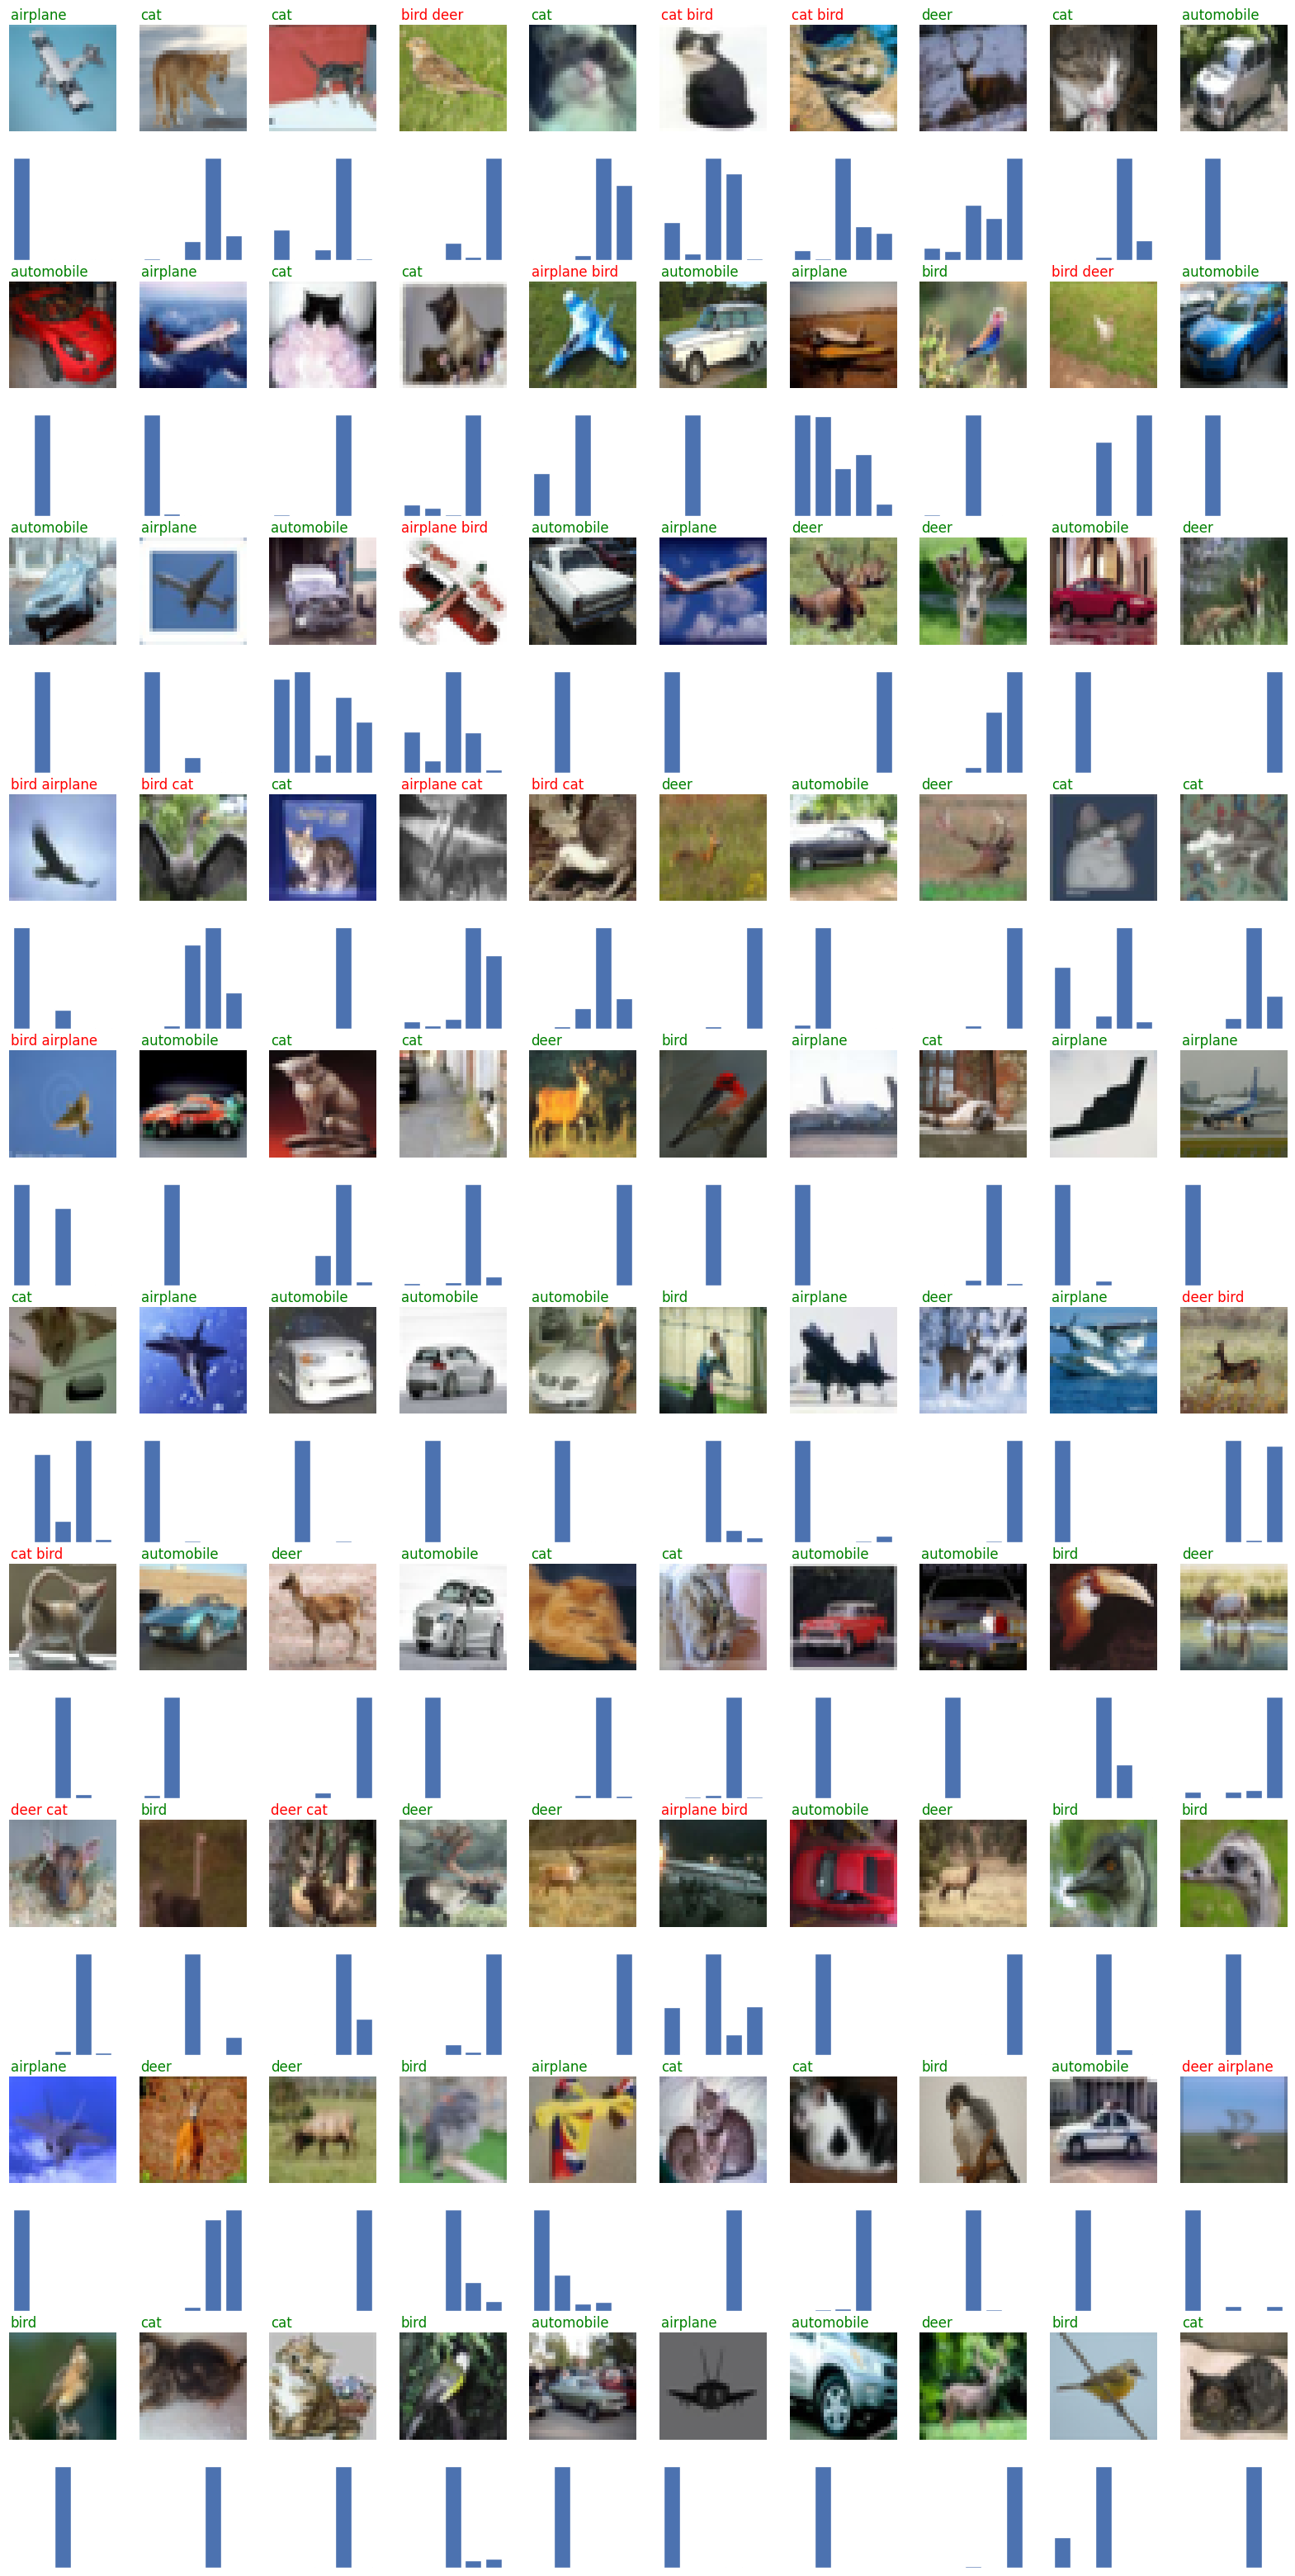

In [62]:
# Names of predicted classes (randomly chosen images)

import random


class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# this construction returns the most probable class for each event
y_pred = np.argmax(model2.predict(x_test), axis = 1)
y_pred_prob = model2.predict(x_test)

grid_w = 10
grid_h = 10

fig = plt.figure(figsize=(20, 40))
for i in range(0,grid_w*grid_h):
    i_pos = 2*(int(i/grid_w))*grid_w+ i%grid_w + 1
    plt.subplot(2*grid_h, grid_w, i_pos)
    i_img = random.randint(0, len(xx_test)-1)
    plt.imshow(xx_test[i_img])
    plt.axis('off')
    if yy_test[i_img] == y_pred[i_img]:
      plt.text(0, -2, class_names[int(yy_test[i_img])], color='green', fontsize=12)
    else:
      plt.text(0, -2, class_names[int(yy_test[i_img])]+" "+class_names[y_pred[i_img]], color='red', fontsize=12)
    plt.subplot(2*grid_h, grid_w, i_pos + grid_w)
    plt.bar(range(num_classes),y_pred_prob[i_img])
    plt.axis('off')

plt.show()

In [63]:
# Confusion matrix result

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
Y_pred = model2.predict(x_test, verbose=2)

y_pred = np.argmax(Y_pred, axis=1)

#confusion matrix
cm = confusion_matrix(np.argmax(y_test,axis=1),y_pred)
print(cm)



157/157 - 0s - 3ms/step
[[880  31  47  26  16]
 [  7 978   3  10   2]
 [ 48  14 746  93  99]
 [ 23  17  78 829  53]
 [ 20   5  56  89 830]]


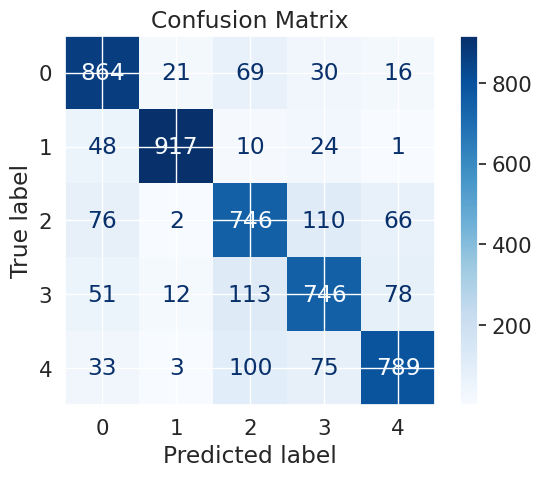

In [68]:
# Visualizing of confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.show()



---



---



---



#<font color='red'>**Want to learn more about deep learning?**

* A great book: **Chollet, Francois. Deep learning with Python.** Simon and Schuster, 2021.

https://file.fouladi.ir/courses/deep/books/Fran%C3%A7ois%20Chollet-Deep%20Learning%20with%20Python-Manning%20(2018)-.pdf

* **Free remote MIT course** - slides, lectures, labs with code examples.

http://introtodeeplearning.com/

